In [1]:
# Test 1: licencias
import wupiengine
print("wupiengine OK")

# Test 2: smartlight virtual
from smartlight.configuration.virtual_configuration import SmartlightVirtualConfig
print("SmartlightVirtualConfig OK")

# Test 3: buscar ficheros .pkl en la carpeta del simulador
import glob, os
pkls = glob.glob("**/*.pkl", recursive=True)
print("Ficheros .pkl encontrados:", pkls)

wupiengine OK
SmartlightVirtualConfig OK
Ficheros .pkl encontrados: []


In [2]:
import pickle, sys
from pathlib import Path

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
# Cargar el fichero de configuración
with open(filepath, 'rb') as f:
    config = pickle.load(f)

# Ver qué contiene
print("Tipo:", type(config))
print()

# Cargar la configuración
cfg = config.load_configuration()
print("Claves:", list(cfg.keys()))
print()

# Ver el WMA
wma = cfg['photonic_processor'].get_wma()
print("Num PUCs:", len(wma.pucs))
print("Nports:", wma.Nports)
print("cells_per_column:", wma.cells_per_column)
print()

# Ver los puertos accesibles
from smartlight.smartlight import Smartlight
sl = Smartlight(filepath, simulation=True)
print("Puertos accesibles:", sl.get_wma_access_ports())

Tipo: <class 'smartlight.configuration.virtual_configuration.SmartlightVirtualConfig'>

Claves: ['photonic_processor', 'meda', 'mema', 'laser', 'calibrated']

Num PUCs: 72
Nports: 40
cells_per_column: [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]

Puertos accesibles: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 34, 35, 36, 37, 38, 39]


In [3]:
from smartlight_puf_ipronics import test_conexion
filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
test_conexion(filepath)

CRITICAL:smartlight.smartlight:Configuration already loaded.


TEST DE CONEXIÓN — SmartLight iPronics Virtual


SmartlightException: Configuration already loaded. Please use disconnect()

In [1]:
from smartlight_puf_ipronics import ejecutar_simulacion_ipronics
from pathlib import Path
from smartlight_puf_v3 import (
    generar_llaves_npz,
    analizar_puf_tfm_final,
    rutas_maestras_anillo,
)
filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"

# Simular (empieza con pocos para verificar)
ejecutar_simulacion_ipronics(
    config_path=filepath,
    n_chips=5,
    n_retos=5,
    rutas_anillo=rutas_maestras_anillo,
    directorio='db_ipronics_test'
)

# El resto del pipeline es idéntico a v2
generar_llaves_npz('db_ipronics_test')
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

Simulación iPronics: 5 chips x 5 retos
Config             : C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight
Puertos activos    : 28 ([0, 1, 2, 3]...[36, 37, 38, 39])
Directorio salida  : db_ipronics_test/

Inicializando chip virtual... OK

  Chip    1/5 (seed=5000)... ERROR: index 1 is out of bounds for axis 0 with size 1
  Chip    2/5 (seed=5001)... ERROR: index 1 is out of bounds for axis 0 with size 1
  Chip    3/5 (seed=5002)... ERROR: index 1 is out of bounds for axis 0 with size 1
  Chip    4/5 (seed=5003)... ERROR: index 1 is out of bounds for axis 0 with size 1
  Chip    5/5 (seed=5004)... ERROR: index 1 is out of bounds for axis 0 with size 1

✅  Simulación iPronics completada en 'db_ipronics_test/'
Binarizando 0 chips con binarización por columnas...


Binarizando Chips: 0it [00:00, ?it/s]


IndexError: list index out of range

In [4]:
import numpy as np
from smartlight.smartlight import Smartlight
sl.disconnect()
config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'
sl = Smartlight(config_path, simulation=True)

wma = sl.get_wma()
pp = sl.get_photonic_processor()

print("is_trilattice:", wma.is_trilattice)
print("architecture:", wma.architecture)
print("size:", wma.size)

# Probar compute_scattering_trilattice directamente
wavelengths = np.array([1550e-9, 1550.1e-9])
H = wma.compute_scattering_trilattice(wavelengths=wavelengths)
print("Shape H trilattice:", H.shape)
print("H[0,0,1]:", H[0,0,1])

sl.disconnect()

is_trilattice: False
architecture: hexagonal
size: AMF-S


IndexError: list index out of range

Simulación iPronics: 5 chips x 5 retos
Config             : C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight
Puertos activos    : 28 ([0, 1, 2, 3]...[36, 37, 38, 39])
Directorio salida  : db_ipronics_test/

Inicializando chip virtual... OK

  Chip    1/5 (seed=5000)... OK
  Chip    2/5 (seed=5001)... OK
  Chip    3/5 (seed=5002)... OK
  Chip    4/5 (seed=5003)... OK
  Chip    5/5 (seed=5004)... OK

✅  Simulación iPronics completada en 'db_ipronics_test/'
Binarizando 5 chips con binarización por columnas...


Binarizando Retos: 100%|████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 105.63it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   5 chips x 3052 bits/llave
   Unicidad media:      0.0008
   Independencia media: 0.0000
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:803: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(hd_independencia_pre, fill=True, color='#ff7f0e', ax=axes[0,0],
C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


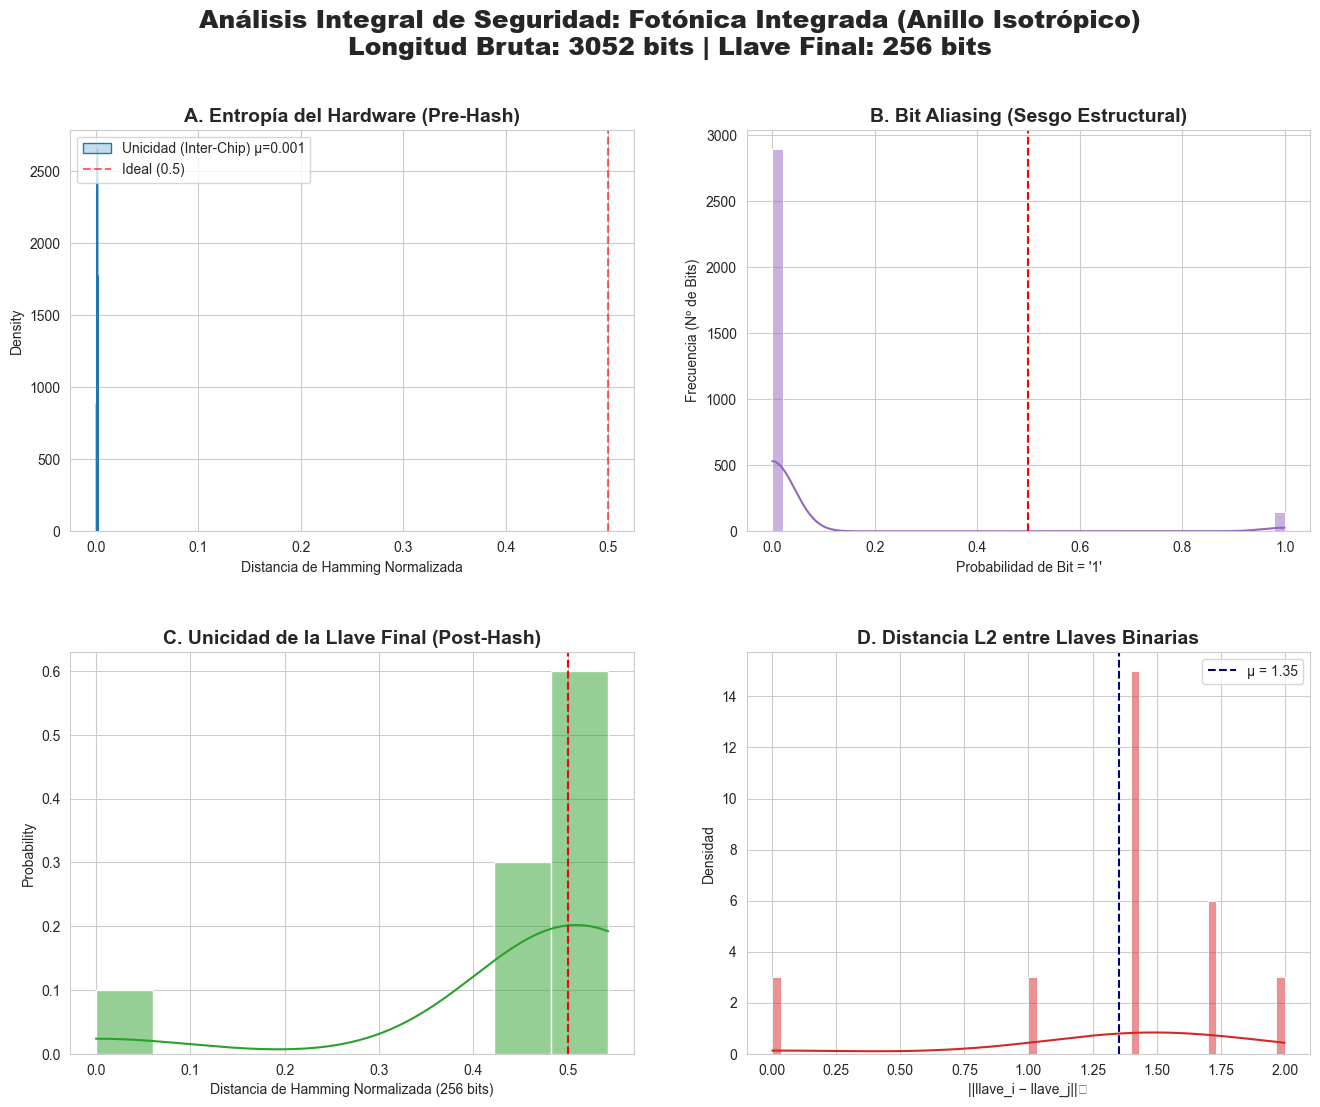


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.0008   |   0.4578   ║
║ Independencia (HD media)       |   0.0000   |   0.0000   ║
║ Uniformidad (Bias)             |   0.0496   |   0.5047   ║
║ Bit Aliasing (Desv. Med)       |   0.4995   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.000787608125819135,
 'unicidad_post': 0.4578125,
 'independencia_pre': 0.0,
 'independencia_post': 0.0,
 'uniformidad_pre': 0.04960681520314548,
 'uniformidad_post': 0.5046875,
 'bit_aliasing_desv': 0.4995412844036697,
 'l2_media': 1.3535169243812561,
 'n_chips': 5,
 'n_bits': 3052}

In [1]:
from smartlight_puf_ipronics import ejecutar_simulacion_ipronics
from smartlight_puf_v3 import (
    generar_llaves_npz,
    analizar_puf_tfm_final,
    rutas_maestras_anillo,
)

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'

ejecutar_simulacion_ipronics(
    config_path=config_path,
    n_chips=5,
    n_retos=5,
    rutas_anillo=rutas_maestras_anillo,
    directorio='db_ipronics_test'
)

generar_llaves_npz('db_ipronics_test')
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

In [2]:
import numpy as np
from smartlight.smartlight import Smartlight
from smartlight_puf_ipronics import (
    _aplicar_fases_pasivas_aleatorias,
    _extraer_params_sdk,
    PUERTOS_ACTIVOS_IPRONICS,
)

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'
sl = Smartlight(config_path, simulation=True)
wma = sl.get_wma()

# Chip 0
_aplicar_fases_pasivas_aleatorias(sl, seed=5000)
params0, fases0, _ = _extraer_params_sdk(sl)
phi1_chip0 = [fases0[(c,f)][0] for (c,f) in list(fases0.keys())[:5]]
print("Chip 0 fases (5 primeras):", phi1_chip0)

# Chip 1
_aplicar_fases_pasivas_aleatorias(sl, seed=5001)
params1, fases1, _ = _extraer_params_sdk(sl)
phi1_chip1 = [fases1[(c,f)][0] for (c,f) in list(fases1.keys())[:5]]
print("Chip 1 fases (5 primeras):", phi1_chip1)

print("\n¿Son iguales?", np.allclose(phi1_chip0, phi1_chip1))

# Ver passive_phase vs driven_phases
puc = wma.pucs[0]
print("\nPUC 0 passive_phase:", puc.passive_phase)
print("PUC 0 driven_phases:", puc.driven_phases)

sl.disconnect()

Chip 0 fases (5 primeras): [0.3436116964863836, 5.056000676871073, 1.1044661672776617, 4.466952054322987, 2.3316507975861747]
Chip 1 fases (5 primeras): [1.4480778637640452, 0.4172427743048944, 4.8351074434155406, 4.8351074434155406, 0.7853981633974483]

¿Son iguales? False

PUC 0 passive_phase: 1.4480778637640452
PUC 0 driven_phases: [0. 0.]


In [1]:
import numpy as np
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import rutas_maestras_anillo
from smartlight_puf_ipronics import (
    _aplicar_fases_pasivas_aleatorias,
    _generar_fases_reto,
    _aplicar_reto_con_ruta,
    _extraer_params_sdk,
)

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'
sl = Smartlight(config_path, simulation=True)
wma = sl.get_wma()
tbus_fijas = {t[0] for ruta in rutas_maestras_anillo.values() for t in ruta}
tbus_dinamicas = [i for i in range(len(wma.pucs)) if i not in tbus_fijas]

mapa = {}
idx = 0
for c, n_filas in enumerate(wma.cells_per_column):
    for f in range(n_filas):
        mapa[idx] = (c, f)
        idx += 1

coords_test = mapa[tbus_dinamicas[0]]

def get_fase(seed_hw, seed_reto):
    _aplicar_fases_pasivas_aleatorias(sl, seed=seed_hw)
    fases = _generar_fases_reto(seed=seed_reto, n_pucs=len(wma.pucs), tbus_fijas=tbus_fijas)
    _aplicar_reto_con_ruta(sl, fases, rutas_maestras_anillo[0])
    _, f, _ = _extraer_params_sdk(sl)
    return f[coords_test][0]

v1 = get_fase(5000, 1)
v2 = get_fase(5001, 1)
v3 = get_fase(5000, 2)
v4 = get_fase(5000, 1)

print(f"Chip 0 reto 1: {v1:.4f}")
print(f"Chip 1 reto 1: {v2:.4f}  ← debe diferir del chip 0")
print(f"Chip 0 reto 2: {v3:.4f}  ← debe diferir del reto 1")
print(f"Chip 0 reto 1: {v4:.4f}  ← debe ser igual al primero")
print()
print("Chip 0 vs Chip 1 difieren:", not np.isclose(v1, v2))
print("Reto 1 vs Reto 2 difieren:", not np.isclose(v1, v3))
print("Reproducibilidad OK:", np.isclose(v1, v4))

sl.disconnect()

Chip 0 reto 1: 6.8477
Chip 1 reto 1: 4.1479  ← debe diferir del chip 0
Chip 0 reto 2: 5.2769  ← debe diferir del reto 1
Chip 0 reto 1: 6.8477  ← debe ser igual al primero

Chip 0 vs Chip 1 difieren: True
Reto 1 vs Reto 2 difieren: True
Reproducibilidad OK: True


Simulación iPronics: 5 chips x 5 retos
Config             : C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight
Puertos activos    : 28 ([0, 1, 2, 3]...[36, 37, 38, 39])
Directorio salida  : db_ipronics_test/

Inicializando chip virtual... OK

  Chip    1/5 (seed=5000)... OK
  Chip    2/5 (seed=5001)... OK
  Chip    3/5 (seed=5002)... OK
  Chip    4/5 (seed=5003)... OK
  Chip    5/5 (seed=5004)... OK

✅  Simulación iPronics completada en 'db_ipronics_test/'
Binarizando 5 chips con binarización por columnas...


Binarizando Retos: 100%|█████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 61.76it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   5 chips x 3052 bits/llave
   Unicidad media:      0.0004
   Independencia media: 0.0000
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:803: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(hd_independencia_pre, fill=True, color='#ff7f0e', ax=axes[0,0],
C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


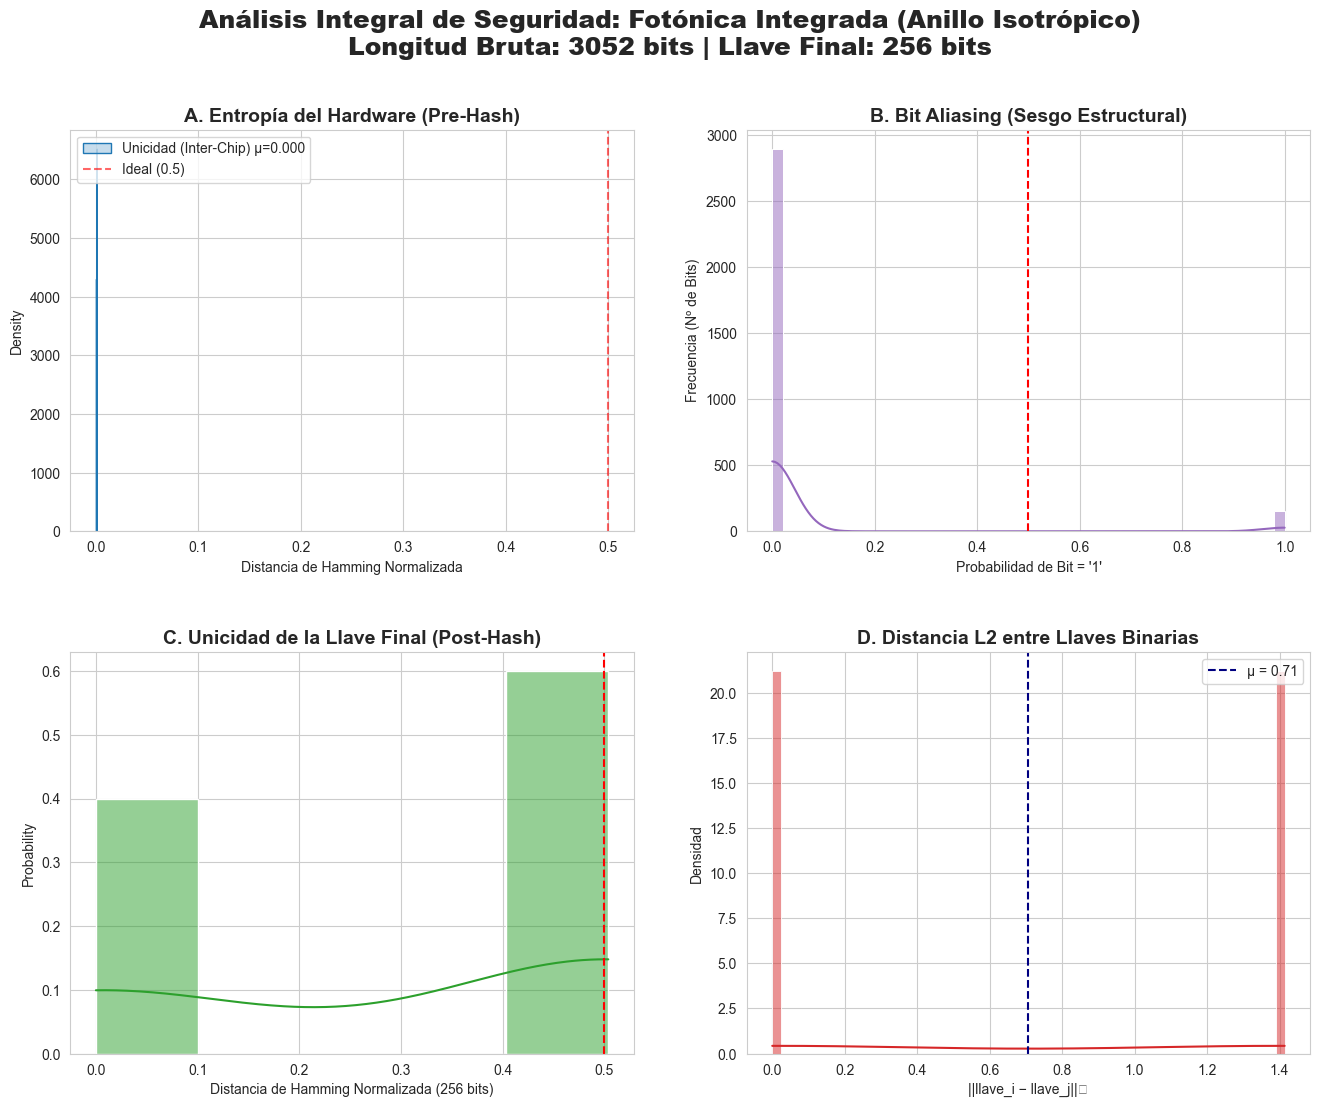


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.0004   |   0.3023   ║
║ Independencia (HD media)       |   0.0000   |   0.0000   ║
║ Uniformidad (Bias)             |   0.0498   |   0.5070   ║
║ Bit Aliasing (Desv. Med)       |   0.4997   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.00039477064220183486,
 'unicidad_post': 0.30234375,
 'independencia_pre': 0.0,
 'independencia_post': 0.0,
 'uniformidad_pre': 0.04980340760157274,
 'uniformidad_post': 0.50703125,
 'bit_aliasing_desv': 0.499737876802097,
 'l2_media': 0.7071067690849304,
 'n_chips': 5,
 'n_bits': 3052}

In [2]:
from smartlight_puf_ipronics import ejecutar_simulacion_ipronics
from smartlight_puf_v3 import (
    generar_llaves_npz,
    analizar_puf_tfm_final,
    rutas_maestras_anillo,
)

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'

ejecutar_simulacion_ipronics(
    config_path=config_path,
    n_chips=5,
    n_retos=5,
    rutas_anillo=rutas_maestras_anillo,
    directorio='db_ipronics_test'
)

generar_llaves_npz('db_ipronics_test')
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

Simulación iPronics: 20 chips x 20 retos
Config             : C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight
Puertos activos    : 28 ([0, 1, 2, 3]...[36, 37, 38, 39])
Directorio salida  : db_ipronics_20/

Inicializando chip virtual... OK

  Chip    1/20 (seed=5000)... OK
  Chip    2/20 (seed=5001)... OK
  Chip    3/20 (seed=5002)... OK
  Chip    4/20 (seed=5003)... OK
  Chip    5/20 (seed=5004)... OK
  Chip    6/20 (seed=5005)... OK
  Chip    7/20 (seed=5006)... OK
  Chip    8/20 (seed=5007)... OK
  Chip    9/20 (seed=5008)... OK
  Chip   10/20 (seed=5009)... OK
  Chip   11/20 (seed=5010)... OK
  Chip   12/20 (seed=5011)... OK
  Chip   13/20 (seed=5012)... OK
  Chip   14/20 (seed=5013)... OK
  Chip   15/20 (seed=5014)... OK
  Chip   16/20 (seed=5015)... OK
  Chip   17/20 (seed=5016)... OK
  Chip   18/20 (seed=5017)... OK
  Chip   19/20 (seed=5018)... OK
  Chip   20/20 (seed=5019)... OK

✅  Simulación iPronics completada en 

Binarizando Retos: 100%|███████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 94.91it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   20 chips x 3052 bits/llave
   Unicidad media:      0.0007
   Independencia media: 0.0001
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


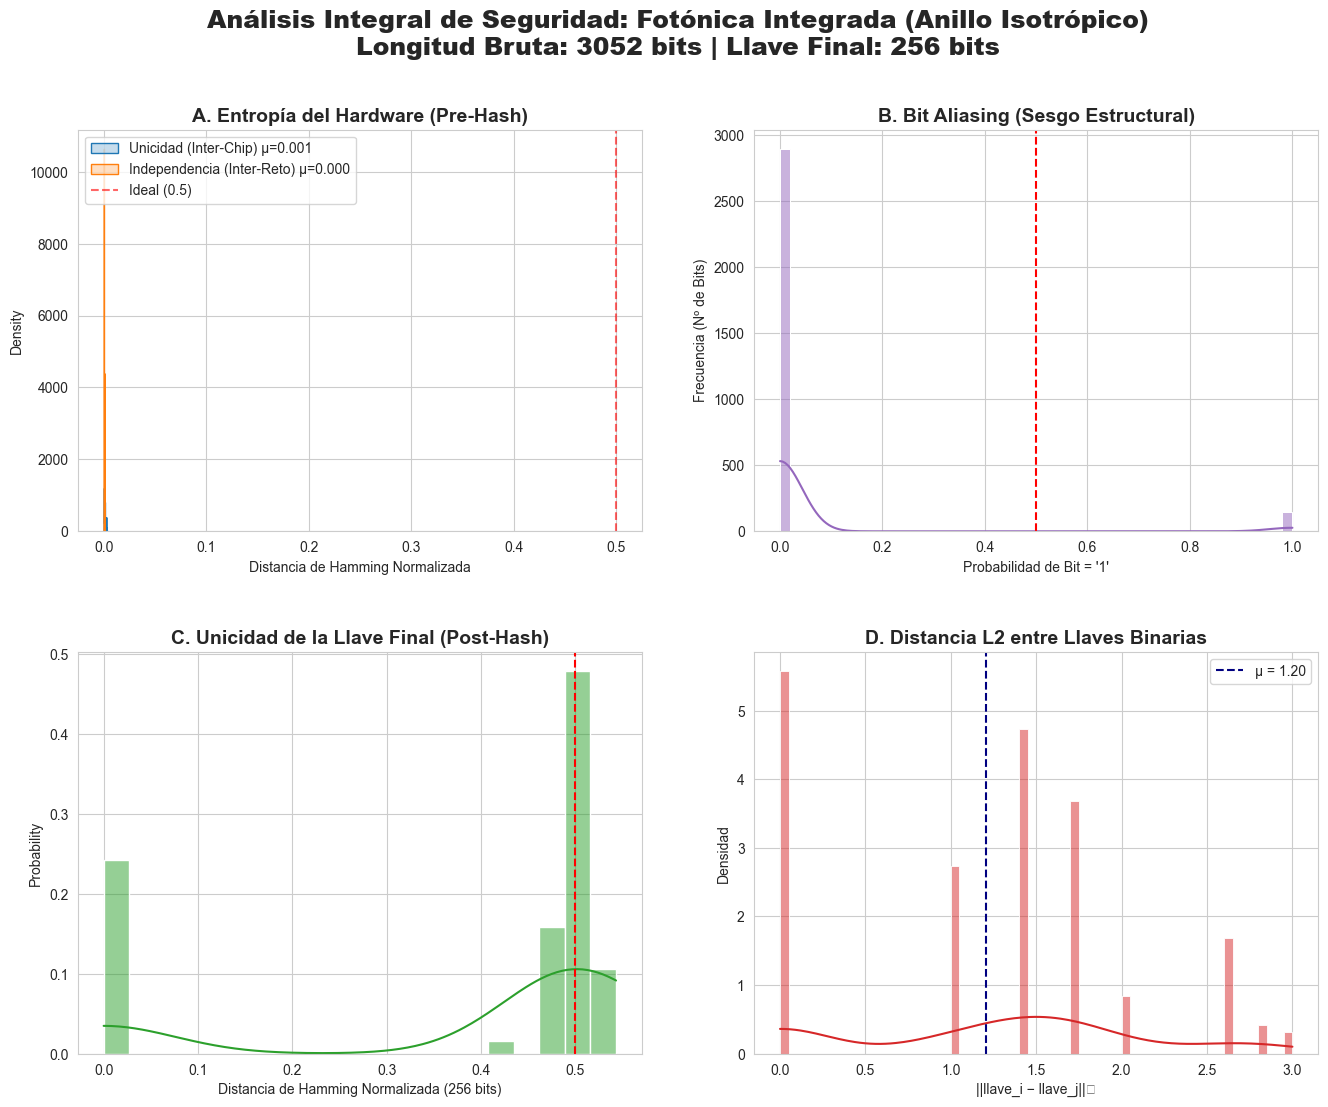


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.0007   |   0.3796   ║
║ Independencia (HD media)       |   0.0001   |   0.1763   ║
║ Uniformidad (Bias)             |   0.0496   |   0.5016   ║
║ Bit Aliasing (Desv. Med)       |   0.4995   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.0007174770642201834,
 'unicidad_post': 0.37964638157894737,
 'independencia_pre': 0.00014338794233289645,
 'independencia_post': 0.1763157894736842,
 'uniformidad_pre': 0.04959043250327654,
 'uniformidad_post': 0.5015625,
 'bit_aliasing_desv': 0.4994921363040629,
 'l2_media': 1.2047742868724622,
 'n_chips': 20,
 'n_bits': 3052}

In [4]:
import numpy as np
from smartlight_puf_ipronics import ejecutar_simulacion_ipronics
from smartlight_puf_v3 import generar_llaves_npz, analizar_puf_tfm_final, rutas_maestras_anillo
import shutil, os

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'

# Limpiar
if os.path.exists('db_ipronics_20'): shutil.rmtree('db_ipronics_20')

ejecutar_simulacion_ipronics(
    config_path=config_path,
    n_chips=20,
    n_retos=20,
    rutas_anillo=rutas_maestras_anillo,
    directorio='db_ipronics_20'
)

generar_llaves_npz('db_ipronics_20')
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

In [1]:
import numpy as np
import time
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import rutas_maestras_anillo
from smartlight_puf_ipronics import (
    _aplicar_fases_pasivas_aleatorias,
    PUERTOS_ACTIVOS_IPRONICS,
)
from smartlight_puf_ipronics import _simular_chip_con_sl

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'
sl = Smartlight(config_path, simulation=True)

t0 = time.time()
_simular_chip_con_sl(sl, chip_idx=99, n_retos=5,
                     rutas_anillo=rutas_maestras_anillo,
                     directorio='db_test_speed')
dt = time.time() - t0
print(f"1 chip x 5 retos: {dt:.1f}s")
print(f"Estimación 50 chips x 50 retos: {50 * (dt/5) * 50 / 60:.1f} minutos")

sl.disconnect()

1 chip x 5 retos: 2.1s
Estimación 50 chips x 50 retos: 17.5 minutos


In [2]:
import time
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import rutas_maestras_anillo
from smartlight_puf_ipronics import _simular_chip_con_sl
import shutil, os

config_path = r'C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\res\hw_config_virtual_amf_s.smartlight'
sl = Smartlight(config_path, simulation=True)

if os.path.exists('db_test_speed'): shutil.rmtree('db_test_speed')

t0 = time.time()
_simular_chip_con_sl(sl, chip_idx=99, n_retos=5,
                     rutas_anillo=rutas_maestras_anillo,
                     directorio='db_test_speed')
dt = time.time() - t0
print(f"1 chip x 5 retos: {dt:.2f}s")
print(f"Estimación 50x50: {50*(dt/5)*50/60:.1f} min")
print(f"Estimación 1000x1000: {1000*(dt/5)*1000/3600:.1f} horas")

sl.disconnect()

1 chip x 5 retos: 2.20s
Estimación 50x50: 18.4 min
Estimación 1000x1000: 122.5 horas


In [1]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    binarizar_puf_lehmer_por_columnas,
    rutas_maestras_anillo,
)
import numpy as np

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
smart = Smartlight(filepath=filepath, simulation=True)

PUERTOS_ACTIVOS = [i for i in range(40) if i < 22 or i > 33]
N = len(PUERTOS_ACTIVOS)

def capturar_matriz_puf(smart, ruta_anillo_config):
    """
    Captura la matriz de potencias N×N inyectando por cada puerto activo.
    Compatible con chip real (simulation=False) y virtual (simulation=True).
    """
    N = len(PUERTOS_ACTIVOS)
    matriz = np.zeros((N, N), dtype=np.float32)

    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        # Programar ruta del Anillo para este puerto
        smart.reset_mesh()
        smart.interconnect(ruta_anillo_config.get(p_in, []))

        # Leer potencias en todos los demás puertos
        puertos_salida = [p for p in PUERTOS_ACTIVOS if p != p_in]
        smart.get_spectral_response(inport=p_in, outports=puertos_salida)

        # Extraer potencias del resultado
        pp = smart.get_photonic_processor()
        H = pp.measured_scattering_matrix["scattering_matrix"]
        # H shape: (n_wl, Nports_pp, Nports_pp)
        # Usar wl_idx=0 y mapping de puertos
        mapping = pp.mapping_wma_mua
        idx_in_pp = mapping[p_in]

        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                idx_out_pp = mapping[p_out]
                potencia_lineal = abs(H[0, idx_out_pp, idx_in_pp])**2
                matriz[idx_fila, idx_col] = potencia_lineal

    return matriz

# Test: capturar una matriz y binarizar
matriz = capturar_matriz_puf(smart, rutas_maestras_anillo)
print("Matriz shape:", matriz.shape)
print("Máximo:", matriz.max())
print("No nulos:", np.count_nonzero(matriz))

firma = binarizar_puf_lehmer_por_columnas(matriz)
print(f"Firma: {len(firma)} bits")
print(f"Primeros 32: {firma[:32]}")

smart.disconnect()

Matriz shape: (28, 28)
Máximo: 0.6142564
No nulos: 756
Firma: 3052 bits
Primeros 32: 10110010111111110011001000101011


Simulando 10 chips x 3 retos con SDK iPronics...
  Chip 1/10 — ya existe
  Chip 2/10 — ya existe
  Chip 3/10 — ya existe
  Chip 4/10 (seed=7003)... OK
  Chip 5/10 (seed=7004)... OK
  Chip 6/10 (seed=7005)... OK
  Chip 7/10 (seed=7006)... OK
  Chip 8/10 (seed=7007)... OK
  Chip 9/10 (seed=7008)... OK
  Chip 10/10 (seed=7009)... OK
Simulación completada.
Binarizando 10 chips con binarización por columnas...


Binarizando Retos: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 86.74it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   10 chips x 3052 bits/llave
   Unicidad media:      0.4246
   Independencia media: 0.0000
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:803: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(hd_independencia_pre, fill=True, color='#ff7f0e', ax=axes[0,0],
C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


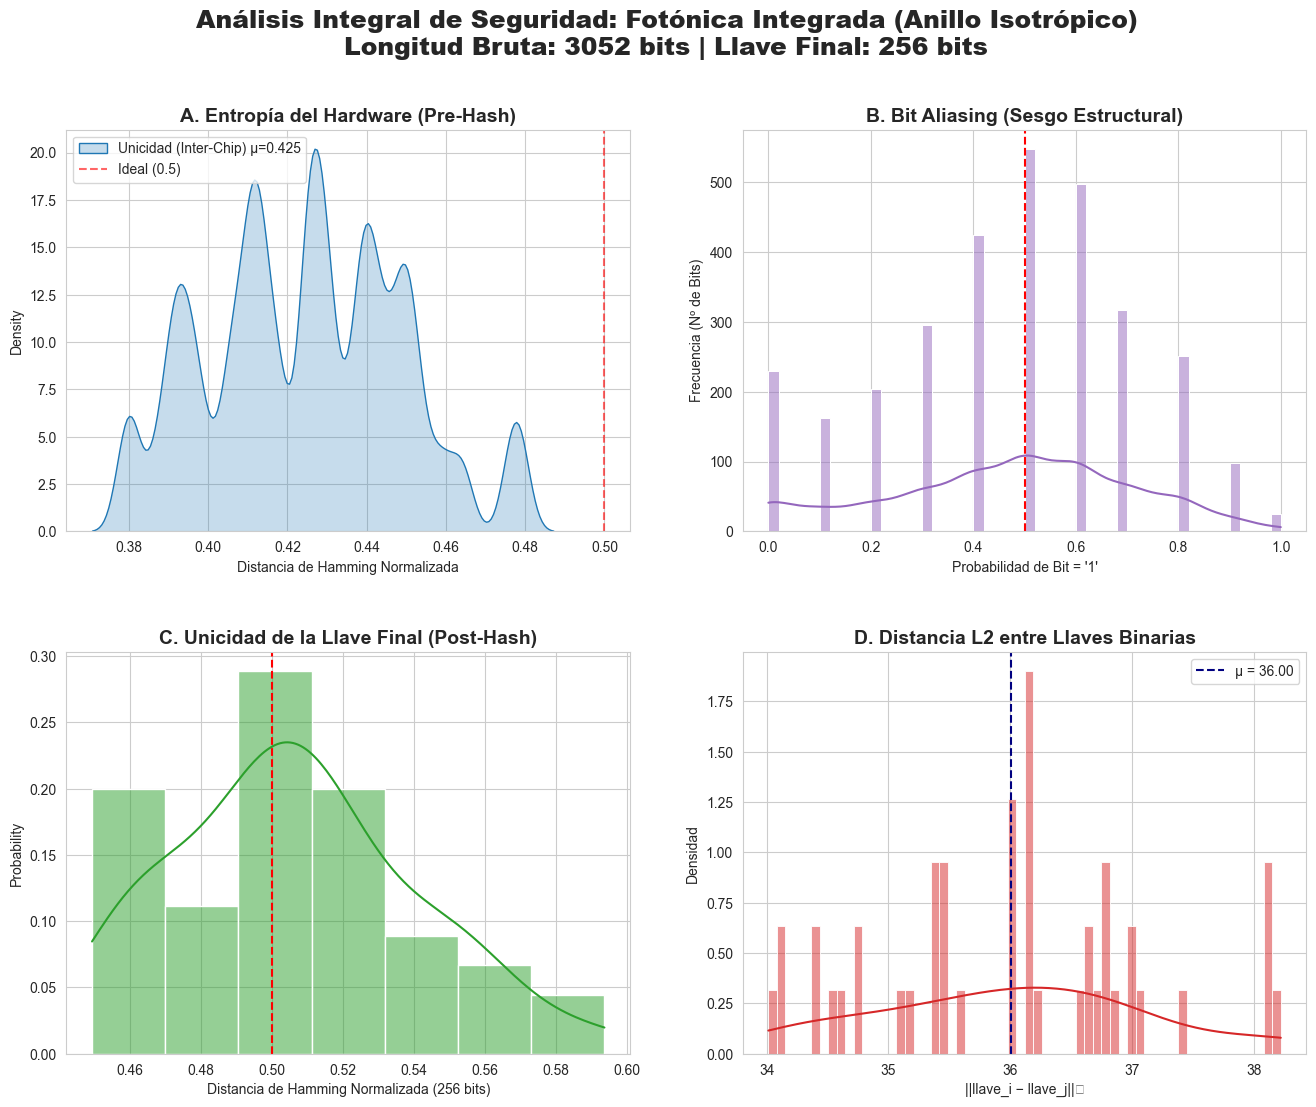


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.4246   |   0.5063   ║
║ Independencia (HD media)       |   0.0000   |   0.0000   ║
║ Uniformidad (Bias)             |   0.4665   |   0.4918   ║
║ Bit Aliasing (Desv. Med)       |   0.1909   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.42458669069462646,
 'unicidad_post': 0.5063368055555556,
 'independencia_pre': 0.0,
 'independencia_post': 0.0,
 'uniformidad_pre': 0.466480996068152,
 'uniformidad_post': 0.491796875,
 'bit_aliasing_desv': 0.19085845347313238,
 'l2_media': 36.004793124728735,
 'n_chips': 10,
 'n_bits': 3052}

In [1]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    binarizar_puf_lehmer_por_columnas,
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
import numpy as np
import os

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
PUERTOS_ACTIVOS = [i for i in range(40) if i < 22 or i > 33]
N = len(PUERTOS_ACTIVOS)

def aplicar_adn_chip(smart, seed):
    """Simula variabilidad de fabricación cambiando fases pasivas."""
    rng = np.random.default_rng(seed)
    wma = smart.get_wma()
    delta_phi = 2 * np.pi / 256
    for puc in wma.pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

def capturar_matriz_puf(smart, ruta_anillo_config):
    """Captura la matriz N×N de potencias."""
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        smart.reset_mesh()
        smart.interconnect(ruta_anillo_config.get(p_in, []))
        puertos_salida = [p for p in PUERTOS_ACTIVOS if p != p_in]
        smart.get_spectral_response(inport=p_in, outports=puertos_salida)
        pp = smart.get_photonic_processor()
        H = pp.measured_scattering_matrix["scattering_matrix"]
        mapping = pp.mapping_wma_mua
        idx_in_pp = mapping[p_in]
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                idx_out_pp = mapping[p_out]
                matriz[idx_fila, idx_col] = abs(H[0, idx_out_pp, idx_in_pp])**2
    return matriz

# Parámetros
N_CHIPS  = 10
N_RETOS  = 3
DIR_OUT  = 'db_sdk_test'
os.makedirs(DIR_OUT, exist_ok=True)

smart = Smartlight(filepath=filepath, simulation=True)

print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos con SDK iPronics...")
for chip_idx in range(N_CHIPS):
    seed_hw = 7000 + chip_idx
    fname = os.path.join(DIR_OUT, f'chip_{seed_hw}.npz')
    if os.path.exists(fname):
        print(f"  Chip {chip_idx+1}/{N_CHIPS} — ya existe")
        continue

    print(f"  Chip {chip_idx+1}/{N_CHIPS} (seed={seed_hw})...", end=' ', flush=True)

    # Aplicar ADN del chip
    aplicar_adn_chip(smart, seed=seed_hw)

    # Medida base
    base = capturar_matriz_puf(smart, rutas_maestras_anillo)

    # Retos: cambiar solo las fases driven (no las pasivas)
    retos = []
    for r in range(N_RETOS):
        rng = np.random.default_rng(seed_hw + r + 1)
        wma = smart.get_wma()
        delta_phi = 2 * np.pi / 256
        # Programar fases driven aleatorias en TBUs dinámicas
        tbus_fijas = {t[0] for ruta in rutas_maestras_anillo.values()
                      for t in ruta}
        for puc_id, puc in enumerate(wma.pucs):
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])

        m_reto = capturar_matriz_puf(smart, rutas_maestras_anillo)
        retos.append(m_reto)

    np.savez_compressed(fname,
                        base_anillo=base,
                        anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print("OK")

smart.disconnect()
print("Simulación completada.")

# Analizar
generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

Benchmark...
  1 matriz: 0.77s
  Estimación 20x20: 5.4 min

Simulando 20 chips x 20 retos...
  Chip   1/20 (seed=8000)... OK (18.4s)
  Chip   2/20 (seed=8001)... OK (17.0s)
  Chip   3/20 (seed=8002)... OK (16.5s)
  Chip   4/20 (seed=8003)... OK (16.9s)
  Chip   5/20 (seed=8004)... OK (16.3s)
  Chip   6/20 (seed=8005)... OK (16.5s)
  Chip   7/20 (seed=8006)... OK (15.2s)
  Chip   8/20 (seed=8007)... OK (14.7s)
  Chip   9/20 (seed=8008)... OK (16.3s)
  Chip  10/20 (seed=8009)... OK (16.5s)
  Chip  11/20 (seed=8010)... OK (16.6s)
  Chip  12/20 (seed=8011)... OK (16.5s)
  Chip  13/20 (seed=8012)... OK (16.9s)
  Chip  14/20 (seed=8013)... OK (17.8s)
  Chip  15/20 (seed=8014)... OK (16.5s)
  Chip  16/20 (seed=8015)... OK (15.8s)
  Chip  17/20 (seed=8016)... OK (15.6s)
  Chip  18/20 (seed=8017)... OK (15.7s)
  Chip  19/20 (seed=8018)... OK (15.6s)
  Chip  20/20 (seed=8019)... OK (16.1s)

✅  Completado en 5.5 min
Binarizando 20 chips con binarización por columnas...


Binarizando Retos: 100%|██████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 100.75it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   20 chips x 3052 bits/llave
   Unicidad media:      0.1838
   Independencia media: 0.1821
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


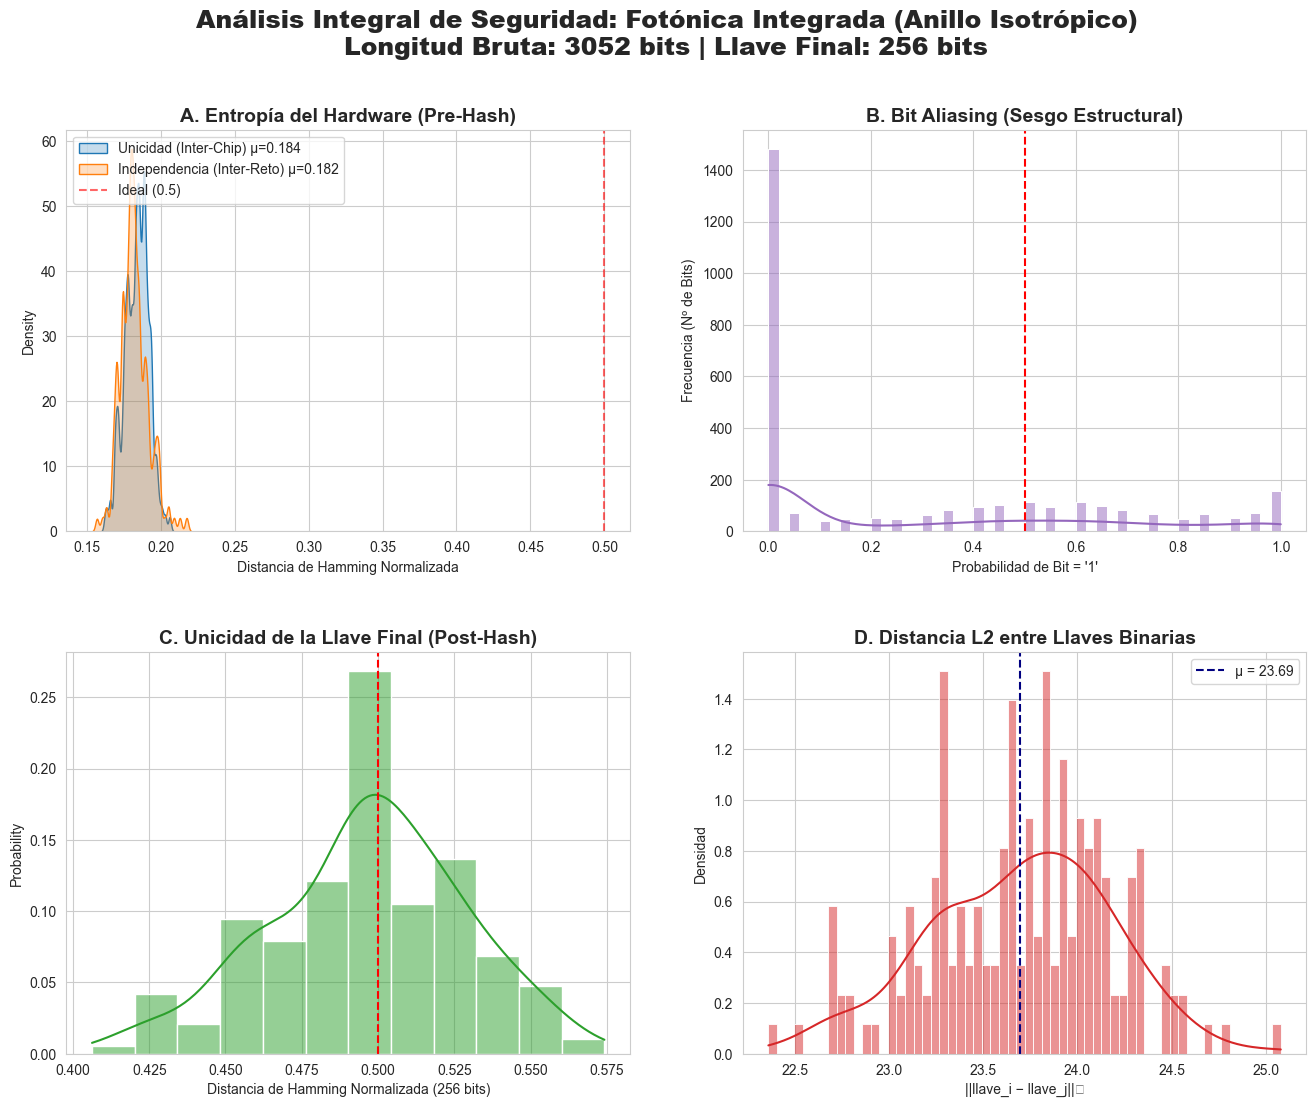


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.1838   |   0.4964   ║
║ Independencia (HD media)       |   0.1821   |   0.5031   ║
║ Uniformidad (Bias)             |   0.2903   |   0.5072   ║
║ Bit Aliasing (Desv. Med)       |   0.3630   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.1838381520314548,
 'unicidad_post': 0.4964432565789474,
 'independencia_pre': 0.18210143512450855,
 'independencia_post': 0.5030838815789473,
 'uniformidad_pre': 0.2903014416775885,
 'uniformidad_post': 0.5072265625,
 'bit_aliasing_desv': 0.3629750982961993,
 'l2_media': 23.694029798005758,
 'n_chips': 20,
 'n_bits': 3052}

In [2]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)
import numpy as np
import os
import time

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def estado_a_driven(estado, passive):
    if estado == "x":      phi = 0.0
    elif estado == "=":    phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2 * np.arcsin(np.sqrt(float(estado)))
    else:                  phi = float(estado[0])
    return phi - passive

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)

    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}

        # Programar fases directamente (rápido)
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])

        # Calcular H con motor SMM rápido
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]

    return matriz

# ── Parámetros ────────────────────────────────────────────
N_CHIPS = 20
N_RETOS = 20
DIR_OUT = 'db_lab_final'
os.makedirs(DIR_OUT, exist_ok=True)

smart = Smartlight(filepath=filepath, simulation=True)

# Benchmark rápido
print("Benchmark...")
aplicar_adn_chip(smart, seed=9999)
t0 = time.time()
capturar_matriz(smart, rutas_maestras_anillo, seed_reto=0)
dt = time.time() - t0
print(f"  1 matriz: {dt:.2f}s")
print(f"  Estimación {N_CHIPS}x{N_RETOS}: "
      f"{N_CHIPS*(N_RETOS+1)*dt/60:.1f} min\n")

# ── Simulación ────────────────────────────────────────────
print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos...")
t_total = time.time()

for chip_idx in range(N_CHIPS):
    seed_hw = 8000 + chip_idx
    fname = os.path.join(DIR_OUT, f'chip_{seed_hw}.npz')
    if os.path.exists(fname):
        print(f"  Chip {chip_idx+1:>3}/{N_CHIPS} — ya existe"); continue

    print(f"  Chip {chip_idx+1:>3}/{N_CHIPS} (seed={seed_hw})...",
          end=' ', flush=True)
    t0 = time.time()

    aplicar_adn_chip(smart, seed=seed_hw)
    base  = capturar_matriz(smart, rutas_maestras_anillo,
                             seed_reto=seed_hw + 777)
    retos = [capturar_matriz(smart, rutas_maestras_anillo,
                              seed_reto=seed_hw + r + 1)
             for r in range(N_RETOS)]

    np.savez_compressed(fname,
                        base_anillo=base,
                        anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print(f"OK ({time.time()-t0:.1f}s)")

smart.disconnect()
print(f"\n✅  Completado en {(time.time()-t_total)/60:.1f} min")

# ── Análisis ─────────────────────────────────────────────
generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

In [4]:
# Arreglar la binarización
from smartlight_puf_v3 import binarizar_puf_lehmer_por_columnas

print("=== FIRMAS BINARIZADAS ===")
firmas = {}
for chip in range(3):
    for r in range(3):
        f_str = binarizar_puf_lehmer_por_columnas(matrices[chip][r])
        # Convertir string de bits a array numpy
        f_arr = np.array([int(b) for b in f_str], dtype=np.uint8)
        firmas[(chip,r)] = f_arr
        print(f"  Chip {chip} Reto {r}: "
              f"fraccion_unos={f_arr.mean():.3f} "
              f"primeros_16={''.join(map(str,f_arr[:16]))}")

print("\n=== HD ENTRE FIRMAS ===")
print(f"  Chip0r0 vs Chip1r0 (unicidad):      "
      f"{np.mean(firmas[(0,0)] != firmas[(1,0)]):.4f}")
print(f"  Chip0r0 vs Chip2r0 (unicidad):      "
      f"{np.mean(firmas[(0,0)] != firmas[(2,0)]):.4f}")
print(f"  Chip0r0 vs Chip0r1 (independencia): "
      f"{np.mean(firmas[(0,0)] != firmas[(0,1)]):.4f}")
print(f"  Chip0r0 vs Chip0r2 (independencia): "
      f"{np.mean(firmas[(0,0)] != firmas[(0,2)]):.4f}")
print(f"  Chip0r0 vs Chip0r0 (reproducib):    "
      f"{np.mean(firmas[(0,0)] != firmas[(0,0)]):.4f}")

=== FIRMAS BINARIZADAS ===
  Chip 0 Reto 0: fraccion_unos=0.281 primeros_16=1001001011001101
  Chip 0 Reto 1: fraccion_unos=0.280 primeros_16=1001001001001101
  Chip 0 Reto 2: fraccion_unos=0.285 primeros_16=1001001011001101
  Chip 1 Reto 0: fraccion_unos=0.287 primeros_16=1001001001001101
  Chip 1 Reto 1: fraccion_unos=0.290 primeros_16=1001001011001101
  Chip 1 Reto 2: fraccion_unos=0.288 primeros_16=1001001001001101
  Chip 2 Reto 0: fraccion_unos=0.296 primeros_16=1001001001001011
  Chip 2 Reto 1: fraccion_unos=0.294 primeros_16=1001001111011001
  Chip 2 Reto 2: fraccion_unos=0.289 primeros_16=1001001001001101

=== HD ENTRE FIRMAS ===
  Chip0r0 vs Chip1r0 (unicidad):      0.1871
  Chip0r0 vs Chip2r0 (unicidad):      0.1779
  Chip0r0 vs Chip0r1 (independencia): 0.1946
  Chip0r0 vs Chip0r2 (independencia): 0.1786
  Chip0r0 vs Chip0r0 (reproducib):    0.0000


In [1]:
import numpy as np
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import rutas_maestras_anillo
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def aplicar_adn_chip_completo(smart, seed):
    """
    Aplica variabilidad de fabricación completa:
    - Fases pasivas: uniforme [0, 2pi]
    - K acopladores: N(0.5, 0.0433) — igual que tu Gemelo Digital
    """
    rng = np.random.default_rng(seed)
    wma = smart.get_wma()

    for puc in wma.pucs:
        # Fase pasiva aleatoria
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

        # K aleatorio N(0.5, 0.0433) para cada acoplador
        for coupler in puc.couplers:
            K_nuevo = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
            # theta tal que sin²(theta) = K
            theta = float(np.arcsin(np.sqrt(K_nuevo)))
            # Los coupling_coefficients son [theta_0, coef_lineal, coef_cuadratico]
            # Solo cambiamos el término constante, mantenemos los otros
            coefs = list(coupler.coupling_coefficients)
            coefs[0] = theta
            coupler.set_coupling_coefficients(coefs)

def estado_a_driven(estado, passive):
    if estado == "x":    phi = 0.0
    elif estado == "=":  phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2*np.arcsin(np.sqrt(float(estado)))
    else: phi = float(estado[0])
    return phi - passive

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]
    return matriz

# Test rápido con 3 chips
smart = Smartlight(filepath=filepath, simulation=True)

firmas = {}
for chip in range(3):
    aplicar_adn_chip_completo(smart, seed=8000+chip)
    for r in range(3):
        m = capturar_matriz(smart, rutas_maestras_anillo,
                             seed_reto=8000+chip+r+1)
        f_str = __import__('smartlight_puf_v3').binarizar_puf_lehmer_por_columnas(m)
        f_arr = np.array([int(b) for b in f_str], dtype=np.uint8)
        firmas[(chip,r)] = f_arr
        print(f"Chip {chip} Reto {r}: fraccion_unos={f_arr.mean():.3f} "
              f"primeros_16={''.join(map(str,f_arr[:16]))}")

print("\nHD unicidad  chip0 vs chip1:", 
      np.mean(firmas[(0,0)] != firmas[(1,0)]))
print("HD independ  chip0 r0 vs r1:", 
      np.mean(firmas[(0,0)] != firmas[(0,1)]))

smart.disconnect()

Chip 0 Reto 0: fraccion_unos=0.305 primeros_16=1111001001101101
Chip 0 Reto 1: fraccion_unos=0.308 primeros_16=1111001001100101
Chip 0 Reto 2: fraccion_unos=0.309 primeros_16=1111001001100111
Chip 1 Reto 0: fraccion_unos=0.306 primeros_16=1111001001000100
Chip 1 Reto 1: fraccion_unos=0.308 primeros_16=1111001001100111
Chip 1 Reto 2: fraccion_unos=0.306 primeros_16=1111001001000101
Chip 2 Reto 0: fraccion_unos=0.300 primeros_16=1111001111001101
Chip 2 Reto 1: fraccion_unos=0.303 primeros_16=1111001001100101
Chip 2 Reto 2: fraccion_unos=0.302 primeros_16=1111001011001101

HD unicidad  chip0 vs chip1: 0.19495412844036697
HD independ  chip0 r0 vs r1: 0.20543905635648754


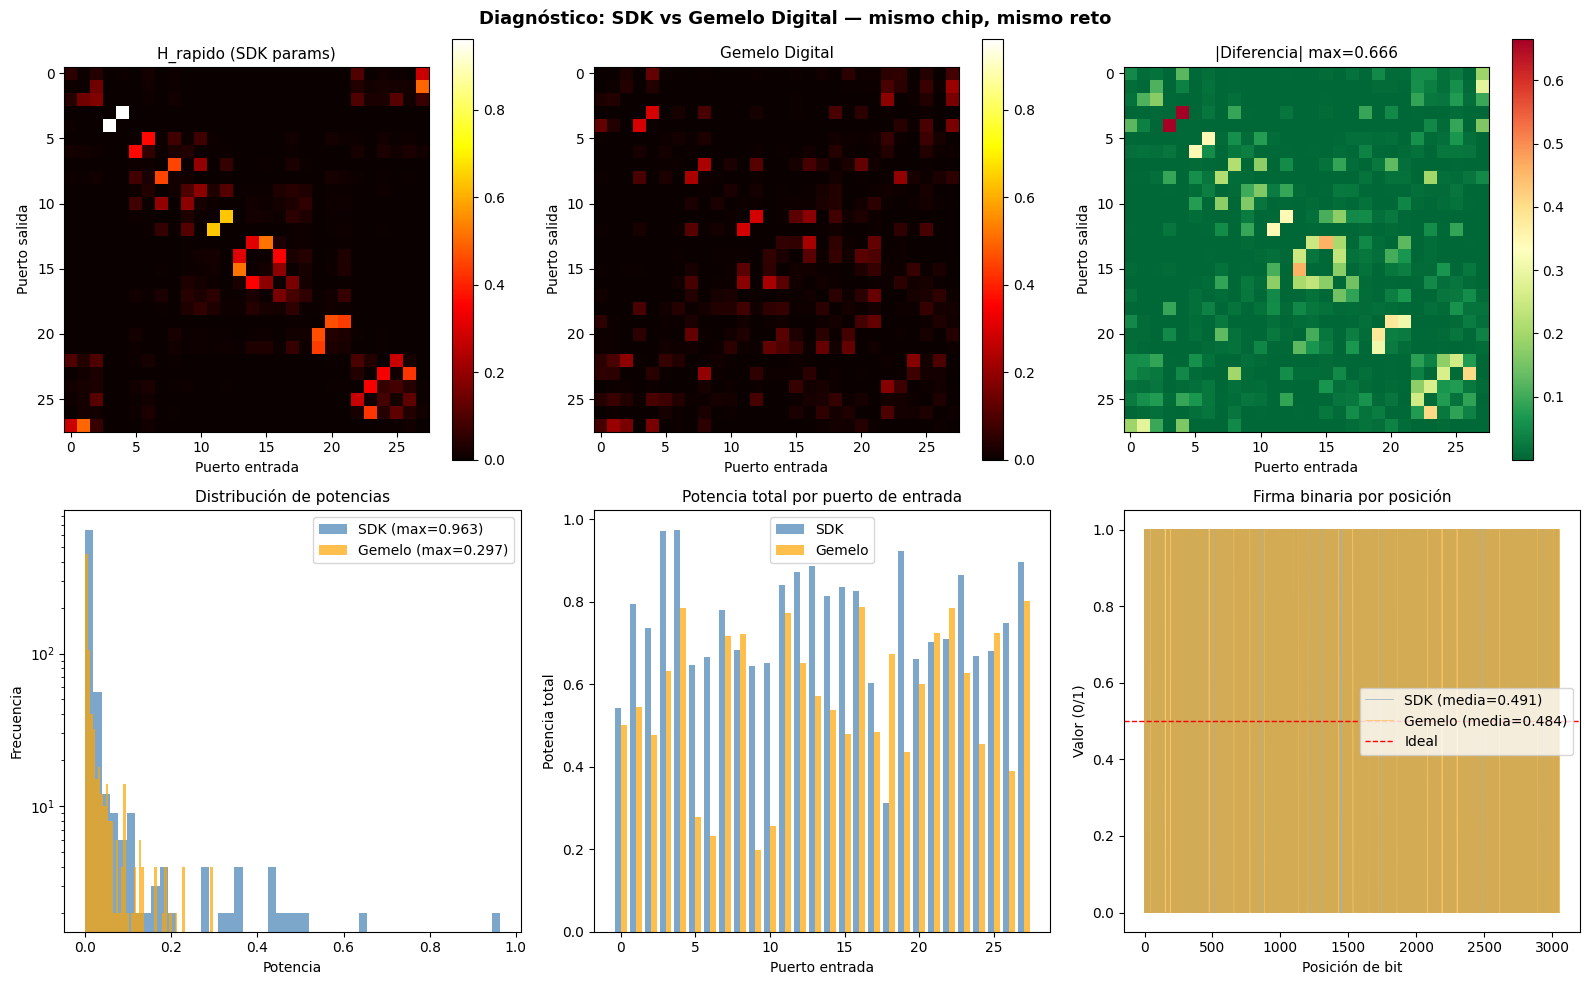

Guardado: diagnostico_heatmap.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    malla_SNM_completa,
    binarizar_puf_lehmer_por_columnas,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
    _extraer_params_sdk,
)

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
TBUS_COL = [6,3,6,4,6,3,6,4,6,3,6,4,6,3,6]
delta_phi = 2 * np.pi / 256
N = len(PUERTOS_ACTIVOS)

smart = Smartlight(filepath=filepath, simulation=True)
wma = smart.get_wma()

# Aplicar ADN completo
rng = np.random.default_rng(8000)
for puc in wma.pucs:
    fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
    puc.set_passive_phase_design(fase)
    for coupler in puc.couplers:
        K_nuevo = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
        theta = float(np.arcsin(np.sqrt(K_nuevo)))
        coefs = list(coupler.coupling_coefficients)
        coefs[0] = theta
        coupler.set_coupling_coefficients(coefs)

# Programar reto aleatorio
rng2 = np.random.default_rng(1)
ruta_p0 = rutas_maestras_anillo.get(0, [])
tbus_fijas_p0 = {puc_id: estado for puc_id, estado in ruta_p0}
for puc_id in range(len(wma.pucs)):
    puc = wma.pucs[puc_id]
    if puc_id not in tbus_fijas_p0:
        fase = round(rng2.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.driven_phases = np.array([fase, 0.0])
    else:
        estado = tbus_fijas_p0[puc_id]
        if estado == "x":   phi = 0.0
        elif estado == "=": phi = np.pi
        elif isinstance(estado, (int, float)):
            phi = 2*np.arcsin(np.sqrt(float(estado)))
        else: phi = float(estado[0])
        puc.driven_phases = np.array([phi - puc.passive_phase, 0.0])

# Calcular H con SDK rapido
H_sdk = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)

# Calcular H con tu Gemelo Digital (mismo chip)
params, fases, _ = _extraer_params_sdk(smart)
malla = malla_SNM_completa(TBUS_COL, seed=None)
for coords, p in params.items():
    malla.params_tbus[coords] = {
        'K_a': p['K_a'], 'K_b': p['K_b'],
        'gamma_a': p['gamma_a'], 'gamma_b': p['gamma_b'],
        'gamma_c': 0.0, 'gamma_d': 0.0,
    }
for coords, (phi1, phi2) in fases.items():
    malla.fases_pasivas[coords] = (phi1, phi2)
config_nulo = [(idx, (0.0, 0.0)) for idx in malla.mapa_tbus.keys()]
malla.programar_malla(config_nulo, ids_maestros=set(malla.mapa_tbus.keys()))
ids_40 = malla.obtener_ids_perimetrales_ordenados()
ids_activos = [ids_40[i] for i in PUERTOS_ACTIVOS]
H_gem = np.abs(malla.resolver_matriz_total(ids_activos))**2

smart.disconnect()

# ── Figura ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Fila 1: matrices de potencia completas
vmax = max(H_sdk.max(), H_gem.max())
im0 = axes[0,0].imshow(H_sdk, cmap='hot', vmin=0, vmax=vmax)
axes[0,0].set_title('H_rapido (SDK params)', fontsize=11)
axes[0,0].set_xlabel('Puerto entrada'); axes[0,0].set_ylabel('Puerto salida')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(H_gem, cmap='hot', vmin=0, vmax=vmax)
axes[0,1].set_title('Gemelo Digital', fontsize=11)
axes[0,1].set_xlabel('Puerto entrada'); axes[0,1].set_ylabel('Puerto salida')
plt.colorbar(im1, ax=axes[0,1])

diff = np.abs(H_sdk - H_gem)
im2 = axes[0,2].imshow(diff, cmap='RdYlGn_r')
axes[0,2].set_title(f'|Diferencia| max={diff.max():.3f}', fontsize=11)
axes[0,2].set_xlabel('Puerto entrada'); axes[0,2].set_ylabel('Puerto salida')
plt.colorbar(im2, ax=axes[0,2])

# Fila 2: distribución de potencias por columna (histogramas)
axes[1,0].hist(H_sdk.flatten(), bins=50, color='steelblue', alpha=0.7,
               label=f'SDK (max={H_sdk.max():.3f})')
axes[1,0].hist(H_gem.flatten(), bins=50, color='orange', alpha=0.7,
               label=f'Gemelo (max={H_gem.max():.3f})')
axes[1,0].set_xlabel('Potencia'); axes[1,0].set_ylabel('Frecuencia')
axes[1,0].set_title('Distribución de potencias', fontsize=11)
axes[1,0].legend(); axes[1,0].set_yscale('log')

# Distribución de sumas por columna (potencia total por puerto de entrada)
sumas_sdk = H_sdk.sum(axis=0)
sumas_gem = H_gem.sum(axis=0)
x = np.arange(N)
axes[1,1].bar(x-0.2, sumas_sdk, 0.4, label='SDK', color='steelblue', alpha=0.7)
axes[1,1].bar(x+0.2, sumas_gem, 0.4, label='Gemelo', color='orange', alpha=0.7)
axes[1,1].set_xlabel('Puerto entrada'); axes[1,1].set_ylabel('Potencia total')
axes[1,1].set_title('Potencia total por puerto de entrada', fontsize=11)
axes[1,1].legend()

# Distribución de bit aliasing (fracción de 1s por posición)
f_sdk = np.array([int(b) for b in binarizar_puf_lehmer_por_columnas(H_sdk)])
f_gem = np.array([int(b) for b in binarizar_puf_lehmer_por_columnas(H_gem)])
axes[1,2].plot(f_sdk, alpha=0.6, label=f'SDK (media={f_sdk.mean():.3f})',
               color='steelblue', linewidth=0.5)
axes[1,2].plot(f_gem, alpha=0.6, label=f'Gemelo (media={f_gem.mean():.3f})',
               color='orange', linewidth=0.5)
axes[1,2].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Ideal')
axes[1,2].set_xlabel('Posición de bit'); axes[1,2].set_ylabel('Valor (0/1)')
axes[1,2].set_title('Firma binaria por posición', fontsize=11)
axes[1,2].legend()

plt.suptitle('Diagnóstico: SDK vs Gemelo Digital — mismo chip, mismo reto',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnostico_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: diagnostico_heatmap.png")


Simulando 20 chips x 20 retos...
  Chip   1/20... OK
  Chip   2/20... OK
  Chip   3/20... OK
  Chip   4/20... OK
  Chip   5/20... OK
  Chip   6/20... OK
  Chip   7/20... OK
  Chip   8/20... OK
  Chip   9/20... OK
  Chip  10/20... OK
  Chip  11/20... OK
  Chip  12/20... OK
  Chip  13/20... OK
  Chip  14/20... OK
  Chip  15/20... OK
  Chip  16/20... OK
  Chip  17/20... OK
  Chip  18/20... OK
  Chip  19/20... OK
  Chip  20/20... OK
Binarizando 20 chips con binarización por columnas...


Binarizando Retos: 100%|███████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 96.80it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   20 chips x 3052 bits/llave
   Unicidad media:      0.3722
   Independencia media: 0.3757
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


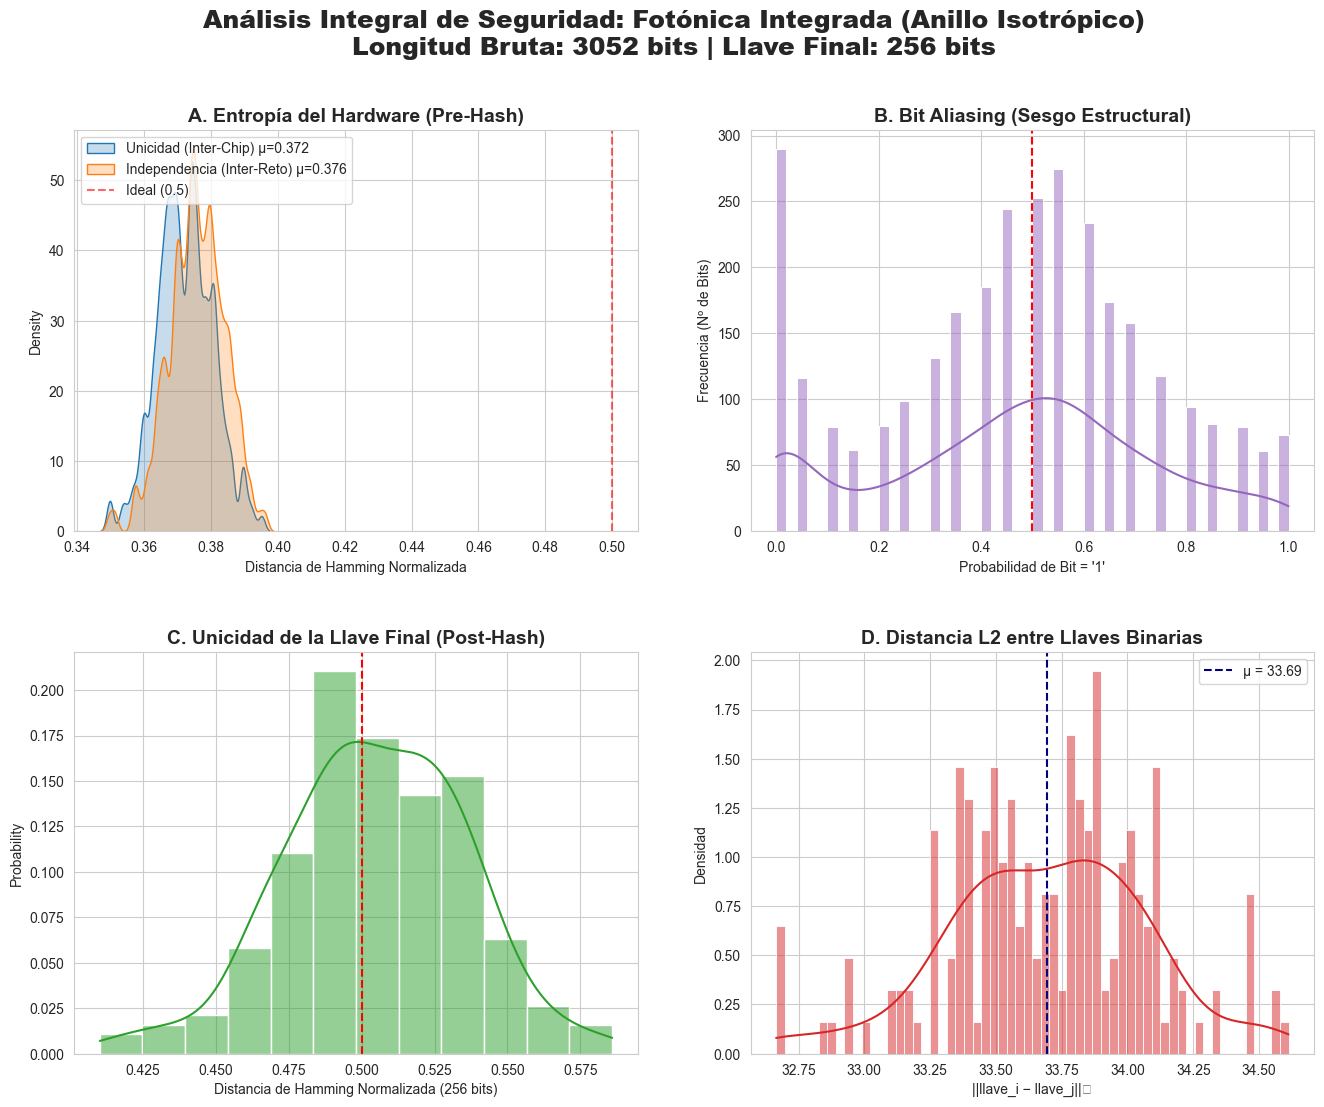


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.3722   |   0.5044   ║
║ Independencia (HD media)       |   0.3757   |   0.4977   ║
║ Uniformidad (Bias)             |   0.4657   |   0.4998   ║
║ Bit Aliasing (Desv. Med)       |   0.2154   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.3722474115334207,
 'unicidad_post': 0.5044202302631579,
 'independencia_pre': 0.37570458060288336,
 'independencia_post': 0.49771792763157896,
 'uniformidad_pre': 0.4657273918741809,
 'uniformidad_post': 0.4998046875,
 'bit_aliasing_desv': 0.21543250327653998,
 'l2_media': 33.694659985994036,
 'n_chips': 20,
 'n_bits': 3052}

In [1]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)
import numpy as np
import os
import shutil

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def estado_a_driven(estado, passive):
    if estado == "x":    phi = 0.0
    elif estado == "=":  phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2*np.arcsin(np.sqrt(float(estado)))
    else: phi = float(estado[0])
    return phi - passive

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)
        for coupler in puc.couplers:
            K = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
            theta = float(np.arcsin(np.sqrt(K)))
            coefs = list(coupler.coupling_coefficients)
            coefs[0] = theta
            coupler.set_coupling_coefficients(coefs)

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]
    return matriz

# Limpiar y lanzar
DIR_OUT = 'db_sdk_corregido'
if os.path.exists(DIR_OUT): shutil.rmtree(DIR_OUT)
os.makedirs(DIR_OUT)

N_CHIPS = 20
N_RETOS = 20

smart = Smartlight(filepath=filepath, simulation=True)
print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos...")

for chip_idx in range(N_CHIPS):
    seed_hw = 9000 + chip_idx
    print(f"  Chip {chip_idx+1:>3}/{N_CHIPS}...", end=' ', flush=True)
    aplicar_adn_chip(smart, seed=seed_hw)
    base  = capturar_matriz(smart, rutas_maestras_anillo, seed_reto=seed_hw+777)
    retos = [capturar_matriz(smart, rutas_maestras_anillo, seed_reto=seed_hw+r+1)
             for r in range(N_RETOS)]
    np.savez_compressed(os.path.join(DIR_OUT, f'chip_{seed_hw}.npz'),
                        base_anillo=base, anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print("OK")

smart.disconnect()

generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

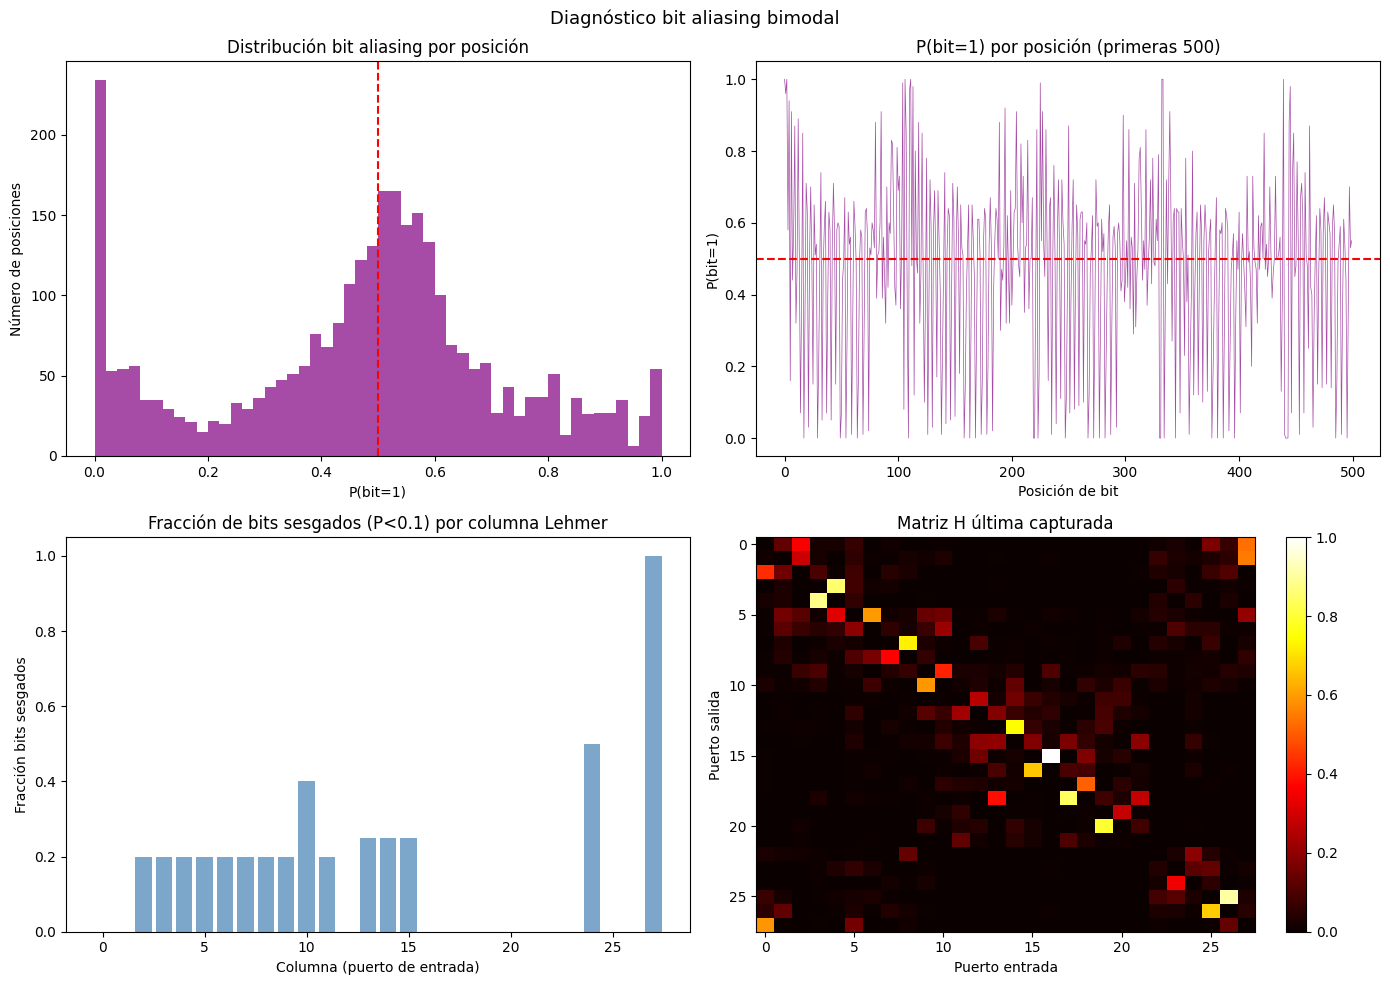

Bits con P(1) < 0.1 (casi siempre 0): 432 (14.2%)
Bits con P(1) > 0.9 (casi siempre 1): 136 (4.5%)
Bits con 0.4 < P(1) < 0.6 (buenos):   1241 (40.7%)

Columnas con más bits sesgados: [27 24 10 15 14]


In [1]:
import numpy as np
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    binarizar_puf_lehmer_por_columnas,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def estado_a_driven(estado, passive):
    if estado == "x":    phi = 0.0
    elif estado == "=":  phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2*np.arcsin(np.sqrt(float(estado)))
    else: phi = float(estado[0])
    return phi - passive

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)
        for coupler in puc.couplers:
            K = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
            theta = float(np.arcsin(np.sqrt(K)))
            coefs = list(coupler.coupling_coefficients)
            coefs[0] = theta
            coupler.set_coupling_coefficients(coefs)

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]
    return matriz

# Capturar 20 chips x 5 retos
smart = Smartlight(filepath=filepath, simulation=True)
firmas = []
for chip in range(20):
    aplicar_adn_chip(smart, seed=9000+chip)
    for r in range(5):
        m = capturar_matriz(smart, rutas_maestras_anillo,
                             seed_reto=9000+chip+r+1)
        f = np.array([int(b) for b in
                       binarizar_puf_lehmer_por_columnas(m)], dtype=np.uint8)
        firmas.append(f)
smart.disconnect()

firmas = np.array(firmas)  # shape (100, 3052)
prob_uno = firmas.mean(axis=0)  # probabilidad de '1' por posición

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución global del bit aliasing
axes[0,0].hist(prob_uno, bins=50, color='purple', alpha=0.7)
axes[0,0].axvline(0.5, color='red', linestyle='--')
axes[0,0].set_title('Distribución bit aliasing por posición')
axes[0,0].set_xlabel('P(bit=1)')
axes[0,0].set_ylabel('Número de posiciones')

# 2. Bit aliasing por posición (primeras 500 posiciones)
axes[0,1].plot(prob_uno[:500], alpha=0.7, linewidth=0.5, color='purple')
axes[0,1].axhline(0.5, color='red', linestyle='--')
axes[0,1].set_title('P(bit=1) por posición (primeras 500)')
axes[0,1].set_xlabel('Posición de bit')
axes[0,1].set_ylabel('P(bit=1)')

# 3. ¿Los bits sesgados (siempre 0) corresponden a qué columna de la firma?
# La firma tiene 28 columnas de Lehmer, cada una de longitud variable
# Identificar qué columna tiene más bits sesgados
n_bits_por_col = []
bits_cero_por_col = []
pos = 0
for col_idx in range(28):
    # Longitud de Lehmer para n-col_idx elementos
    n = 28 - col_idx
    n_bits = int(np.ceil(np.log2(n))) if n > 1 else 1
    bits_col = prob_uno[pos:pos+n_bits]
    n_bits_por_col.append(n_bits)
    bits_cero_por_col.append(np.mean(bits_col < 0.1))  # fracción de bits sesgados
    pos += n_bits

axes[1,0].bar(range(28), bits_cero_por_col, color='steelblue', alpha=0.7)
axes[1,0].set_title('Fracción de bits sesgados (P<0.1) por columna Lehmer')
axes[1,0].set_xlabel('Columna (puerto de entrada)')
axes[1,0].set_ylabel('Fracción bits sesgados')

# 4. Ver potencias de las matrices — ¿hay columnas de H siempre dominadas?
# Cargar la última matriz capturada y ver su estructura
axes[1,1].imshow(m, cmap='hot', aspect='auto')
axes[1,1].set_title('Matriz H última capturada')
axes[1,1].set_xlabel('Puerto entrada')
axes[1,1].set_ylabel('Puerto salida')
plt.colorbar(plt.cm.ScalarMappable(cmap='hot'), ax=axes[1,1])

plt.suptitle('Diagnóstico bit aliasing bimodal', fontsize=13)
plt.tight_layout()
plt.savefig('diagnostico_bit_aliasing.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave
print(f"Bits con P(1) < 0.1 (casi siempre 0): {np.sum(prob_uno < 0.1)} ({100*np.mean(prob_uno < 0.1):.1f}%)")
print(f"Bits con P(1) > 0.9 (casi siempre 1): {np.sum(prob_uno > 0.9)} ({100*np.mean(prob_uno > 0.9):.1f}%)")
print(f"Bits con 0.4 < P(1) < 0.6 (buenos):   {np.sum((prob_uno>0.4)&(prob_uno<0.6))} ({100*np.mean((prob_uno>0.4)&(prob_uno<0.6)):.1f}%)")
print(f"\nColumnas con más bits sesgados: {np.argsort(bits_cero_por_col)[::-1][:5]}")

In [2]:
print("Estadísticas:")
print(f"  Bits con P(1) < 0.1: {np.sum(prob_uno < 0.1)} ({100*np.mean(prob_uno < 0.1):.1f}%)")
print(f"  Bits con P(1) > 0.9: {np.sum(prob_uno > 0.9)} ({100*np.mean(prob_uno > 0.9):.1f}%)")
print(f"  Bits buenos (0.4-0.6): {np.sum((prob_uno>0.4)&(prob_uno<0.6))} ({100*np.mean((prob_uno>0.4)&(prob_uno<0.6)):.1f}%)")
print(f"\nColumnas Lehmer con más bits sesgados (top 5):")
for i in np.argsort(bits_cero_por_col)[::-1][:5]:
    print(f"  Columna {i} (puerto {PUERTOS_ACTIVOS[i]}): {bits_cero_por_col[i]:.2f} fracción sesgada")

Estadísticas:
  Bits con P(1) < 0.1: 432 (14.2%)
  Bits con P(1) > 0.9: 136 (4.5%)
  Bits buenos (0.4-0.6): 1241 (40.7%)

Columnas Lehmer con más bits sesgados (top 5):
  Columna 27 (puerto 39): 1.00 fracción sesgada
  Columna 24 (puerto 36): 0.50 fracción sesgada
  Columna 10 (puerto 10): 0.40 fracción sesgada
  Columna 15 (puerto 15): 0.25 fracción sesgada
  Columna 14 (puerto 14): 0.25 fracción sesgada


NameError: name 'PUERTOS_ACTIVOS' is not defined

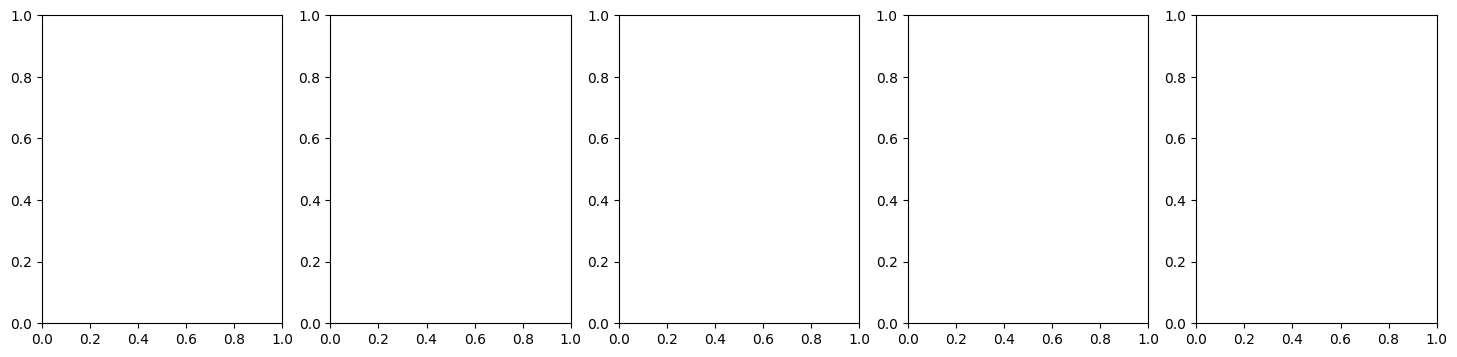

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ver las columnas problemáticas en la matriz H
puertos_problematicos = [27, 24, 10, 15, 14]  # índices en PUERTOS_ACTIVOS

fig, axes = plt.subplots(1, len(puertos_problematicos), figsize=(18, 4))

for ax, col_idx in zip(axes, puertos_problematicos):
    puerto = PUERTOS_ACTIVOS[col_idx]
    col = m[:, col_idx]  # última matriz capturada
    ax.bar(range(N), col, color='steelblue', alpha=0.8)
    ax.set_title(f'Puerto {puerto} (col {col_idx})\nmax={col.max():.3f}')
    ax.set_xlabel('Puerto salida')
    ax.set_ylabel('Potencia')
    ax.axhline(col.mean(), color='red', linestyle='--', linewidth=1)

plt.suptitle('Distribución de potencia en puertos problemáticos', fontsize=12)
plt.tight_layout()
plt.savefig('puertos_problematicos.png', dpi=150, bbox_inches='tight')
plt.show()

# Ver también la ruta del Anillo para estos puertos
print("Rutas del Anillo para puertos problemáticos:")
for col_idx in puertos_problematicos:
    puerto = PUERTOS_ACTIVOS[col_idx]
    ruta = rutas_maestras_anillo.get(puerto, [])
    print(f"\n  Puerto {puerto}: {len(ruta)} TBUs en ruta")
    print(f"    {ruta}")

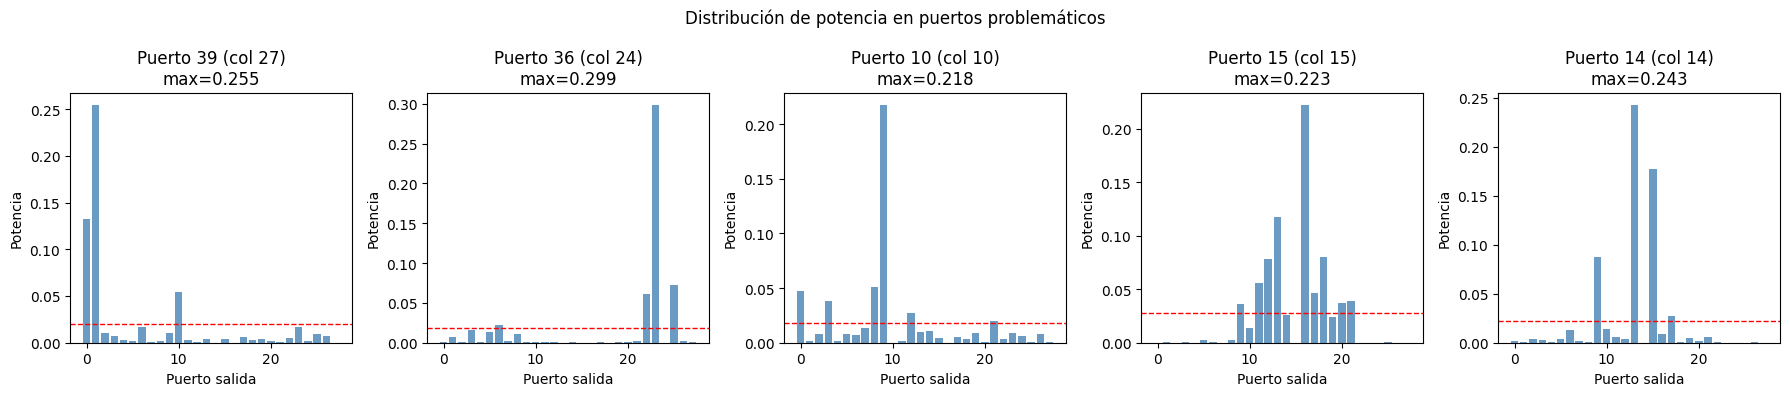

Rutas del Anillo para puertos problemáticos:

  Puerto 39: 12 TBUs en ruta
    [(1, 'x'), (6, '='), (10, 'x'), (16, 'x'), (21, 'x'), (26, 'x'), (31, 'x'), (36, 0.8333333333333334), (41, 0.8), (40, 0.75), (35, 0.6666666666666667), (30, 0.5)]

  Puerto 36: 12 TBUs en ruta
    [(4, 'x'), (8, '='), (13, 'x'), (17, 'x'), (22, 'x'), (26, 'x'), (31, 'x'), (36, 0.8333333333333334), (41, 0.8), (40, 0.75), (35, 0.6666666666666667), (30, 0.5)]

  Puerto 10: 9 TBUs en ruta
    [(47, '='), (44, 'x'), (39, 'x'), (35, 'x'), (30, 0.8333333333333334), (31, 0.8), (36, 0.75), (41, 0.6666666666666667), (40, 0.5)]

  Puerto 15: 12 TBUs en ruta
    [(66, 'x'), (63, 'x'), (58, 'x'), (54, 'x'), (49, 'x'), (45, 'x'), (40, 'x'), (35, 0.8333333333333334), (30, 0.8), (31, 0.75), (36, 0.6666666666666667), (41, 0.5)]

  Puerto 14: 12 TBUs en ruta
    [(66, '='), (63, 'x'), (58, 'x'), (54, 'x'), (49, 'x'), (45, 'x'), (40, 'x'), (35, 0.8333333333333334), (30, 0.8), (31, 0.75), (36, 0.6666666666666667), (41, 0.5)]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import rutas_maestras_anillo
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def estado_a_driven(estado, passive):
    if estado == "x":    phi = 0.0
    elif estado == "=":  phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2*np.arcsin(np.sqrt(float(estado)))
    else: phi = float(estado[0])
    return phi - passive

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)
        for coupler in puc.couplers:
            K = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
            theta = float(np.arcsin(np.sqrt(K)))
            coefs = list(coupler.coupling_coefficients)
            coefs[0] = theta
            coupler.set_coupling_coefficients(coefs)

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]
    return matriz

# Capturar una sola matriz para diagnóstico
smart = Smartlight(filepath=filepath, simulation=True)
aplicar_adn_chip(smart, seed=9000)
m = capturar_matriz(smart, rutas_maestras_anillo, seed_reto=1)
smart.disconnect()

# Ver las columnas problemáticas
puertos_problematicos = [27, 24, 10, 15, 14]

fig, axes = plt.subplots(1, len(puertos_problematicos), figsize=(18, 4))
for ax, col_idx in zip(axes, puertos_problematicos):
    puerto = PUERTOS_ACTIVOS[col_idx]
    col = m[:, col_idx]
    ax.bar(range(N), col, color='steelblue', alpha=0.8)
    ax.set_title(f'Puerto {puerto} (col {col_idx})\nmax={col.max():.3f}')
    ax.set_xlabel('Puerto salida')
    ax.set_ylabel('Potencia')
    ax.axhline(col.mean(), color='red', linestyle='--', linewidth=1)

plt.suptitle('Distribución de potencia en puertos problemáticos', fontsize=12)
plt.tight_layout()
plt.savefig('puertos_problematicos.png', dpi=150, bbox_inches='tight')
plt.show()

# Ver rutas del Anillo para estos puertos
print("Rutas del Anillo para puertos problemáticos:")
for col_idx in puertos_problematicos:
    puerto = PUERTOS_ACTIVOS[col_idx]
    ruta = rutas_maestras_anillo.get(puerto, [])
    print(f"\n  Puerto {puerto}: {len(ruta)} TBUs en ruta")
    print(f"    {ruta}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    binarizar_puf_lehmer_por_columnas,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def estado_a_driven(estado, passive):
    if estado == "x":    phi = 0.0
    elif estado == "=":  phi = np.pi
    elif isinstance(estado, (int, float)):
        phi = 2*np.arcsin(np.sqrt(float(estado)))
    else: phi = float(estado[0])
    return phi - passive

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)
        for coupler in puc.couplers:
            K = float(np.clip(rng.normal(0.5, 0.0433), 0.01, 0.99))
            theta = float(np.arcsin(np.sqrt(K)))
            coefs = list(coupler.coupling_coefficients)
            coefs[0] = theta
            coupler.set_coupling_coefficients(coefs)

def capturar_matriz(smart, rutas_anillo, seed_reto):
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = rutas_anillo.get(p_in, [])
        tbus_fijas = {puc_id: estado for puc_id, estado in ruta_puerto}
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            puc = wma.pucs[puc_id]
            if puc_id not in tbus_fijas:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                puc.driven_phases = np.array([fase, 0.0])
            else:
                driven = estado_a_driven(tbus_fijas[puc_id], puc.passive_phase)
                puc.driven_phases = np.array([driven, 0.0])
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS)
        idx_in_local = PUERTOS_ACTIVOS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]
    return matriz

# Capturar 10 chips x 3 retos para diagnóstico rápido
smart = Smartlight(filepath=filepath, simulation=True)
firmas = []
for chip in range(10):
    aplicar_adn_chip(smart, seed=9000+chip)
    for r in range(3):
        m = capturar_matriz(smart, rutas_maestras_anillo,
                             seed_reto=9000+chip+r+1)
        f = np.array([int(b) for b in
                       binarizar_puf_lehmer_por_columnas(m)], dtype=np.uint8)
        firmas.append(f)
smart.disconnect()

firmas = np.array(firmas)
prob_uno = firmas.mean(axis=0)

# Calcular bits sesgados por columna Lehmer
bits_sesgados_por_col = []
pos = 0
for col_idx in range(28):
    n = 28 - col_idx
    n_bits = int(np.ceil(np.log2(n))) if n > 1 else 1
    bits_col = prob_uno[pos:pos+n_bits]
    # Sesgo = desviación media de 0.5
    sesgo = np.mean(np.abs(bits_col - 0.5))
    bits_sesgados_por_col.append(sesgo)
    pos += n_bits

bits_sesgados_por_col = np.array(bits_sesgados_por_col)

# Ordenar puertos por calidad (menor sesgo = mejor)
orden_calidad = np.argsort(bits_sesgados_por_col)
print("Puertos ordenados por calidad (mejor primero):")
for i, col_idx in enumerate(orden_calidad):
    puerto = PUERTOS_ACTIVOS[col_idx]
    print(f"  {i+1:>2}. Col {col_idx:>2} Puerto {puerto:>2} "
          f"sesgo={bits_sesgados_por_col[col_idx]:.3f} "
          f"{'✅' if bits_sesgados_por_col[col_idx] < 0.15 else '⚠️' if bits_sesgados_por_col[col_idx] < 0.25 else '❌'}")

# Umbral: conservar puertos con sesgo < 0.20
buenos = [PUERTOS_ACTIVOS[i] for i in range(28)
          if bits_sesgados_por_col[i] < 0.20]
print(f"\nPuertos buenos (sesgo < 0.20): {len(buenos)}")
print(buenos)

In [1]:
import numpy as np
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    malla_SNM_completa,
    malla_hexagonal,
    TBU_SNM,
)
from smartlight_puf_ipronics import (
    _extraer_params_sdk,
    PUERTOS_ACTIVOS_IPRONICS as PUERTOS_ACTIVOS,
)
import scipy.sparse as sp
from scipy.sparse.linalg import factorized

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
TBUS_COL = [6,3,6,4,6,3,6,4,6,3,6,4,6,3,6]
Filas = max(TBUS_COL)

smart = Smartlight(filepath=filepath, simulation=True)
wma = smart.get_wma()

# ADN chip
delta_phi = 2 * np.pi / 256
rng = np.random.default_rng(8000)
for puc in wma.pucs:
    fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
    puc.set_passive_phase_design(fase)

# Extraer params
params, fases, _ = _extraer_params_sdk(smart)

# Ver el mapping de puertos
malla_ref = malla_SNM_completa(TBUS_COL, seed=None)
ids_40 = malla_ref.obtener_ids_perimetrales_ordenados()
print("ids_40 (primeros 10):", ids_40[:10])
print("PUERTOS_ACTIVOS (primeros 10):", PUERTOS_ACTIVOS[:10])
print()
print("Puerto 0 de la malla -> nodo interno del grafo:", ids_40[0])
print("Puerto 1 de la malla -> nodo interno del grafo:", ids_40[1])
print()

# En _calcular_H_rapido usamos get_nodos(p_ext) donde p_ext es el
# número de puerto (0,1,2...) pero debería ser ids_40[i]
print("¿Coinciden?", ids_40[0] == 0, ids_40[1] == 1)
print("Este es el bug: los puertos no coinciden con los nodos del grafo")

smart.disconnect()

ids_40 (primeros 10): [1, 0, 50, 72, 74, 96, 146, 168, 170, 192]
PUERTOS_ACTIVOS (primeros 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Puerto 0 de la malla -> nodo interno del grafo: 1
Puerto 1 de la malla -> nodo interno del grafo: 0

¿Coinciden? False False
Este es el bug: los puertos no coinciden con los nodos del grafo


In [1]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    binarizar_puf_lehmer_por_columnas,
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
import numpy as np
import os

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
PUERTOS_ACTIVOS = [i for i in range(40) if i < 22 or i > 33]
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def aplicar_adn_chip(smart, seed):
    """Fases pasivas de fabricación únicas por chip."""
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

def estado_a_fases(estado):
    if estado == "x":   return (0.0, 0.0)
    elif estado == "=": return (np.pi, 0.0)
    elif isinstance(estado, (int, float)):
        return (2*np.arcsin(np.sqrt(float(estado))), 0.0)
    return (float(estado[0]), float(estado[1]))

def capturar_matriz_con_reto(smart, ruta_anillo_config, seed_reto):
    """
    Captura la matriz N×N programando para cada puerto:
    - TBUs de la ruta: estado fijo del Anillo
    - TBUs dinámicas: fase aleatoria del reto (misma seed, varía por puerto)
    """
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)
    pp = smart.get_photonic_processor()
    mapping = pp.mapping_wma_mua

    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = ruta_anillo_config.get(p_in, [])
        tbus_fijas_puerto = {t[0] for t in ruta_puerto}
        ruta_dict = {puc_id: estado for puc_id, estado in ruta_puerto}

        # Fases aleatorias del reto para TBUs dinámicas
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            if puc_id not in tbus_fijas_puerto:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                wma.pucs[puc_id].driven_phases = np.array([fase, 0.0])
            else:
                phi1, phi2 = estado_a_fases(ruta_dict[puc_id])
                passive = wma.pucs[puc_id].passive_phase
                wma.pucs[puc_id].driven_phases = np.array([phi1 - passive, phi2])

        # Leer potencias via get_spectral_response
        puertos_salida = [p for p in PUERTOS_ACTIVOS if p != p_in]
        smart.get_spectral_response(inport=p_in, outports=puertos_salida)

        H = pp.measured_scattering_matrix["scattering_matrix"]
        idx_in_pp = mapping[p_in]
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                idx_out_pp = mapping[p_out]
                matriz[idx_fila, idx_col] = abs(H[0, idx_out_pp, idx_in_pp])**2

    return matriz

# Parámetros
N_CHIPS = 5
N_RETOS = 5
DIR_OUT = 'db_sdk_v2'
os.makedirs(DIR_OUT, exist_ok=True)

smart = Smartlight(filepath=filepath, simulation=True)

print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos...")
for chip_idx in range(N_CHIPS):
    seed_hw = 7000 + chip_idx
    fname = os.path.join(DIR_OUT, f'chip_{seed_hw}.npz')
    if os.path.exists(fname):
        print(f"  Chip {chip_idx+1}/{N_CHIPS} — ya existe"); continue

    print(f"  Chip {chip_idx+1}/{N_CHIPS} (seed={seed_hw})...", end=' ', flush=True)
    aplicar_adn_chip(smart, seed=seed_hw)

    base = capturar_matriz_con_reto(smart, rutas_maestras_anillo,
                                     seed_reto=seed_hw + 777)
    retos = []
    for r in range(N_RETOS):
        m = capturar_matriz_con_reto(smart, rutas_maestras_anillo,
                                      seed_reto=seed_hw + r + 1)
        retos.append(m)

    np.savez_compressed(fname,
                        base_anillo=base,
                        anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print("OK")

smart.disconnect()

generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

Simulando 5 chips x 5 retos...
  Chip 1/5 (seed=7000)... 


KeyboardInterrupt



Simulando 20 chips x 20 retos (motor rápido)...
  Chip 1/20 (seed=7000)... OK
  Chip 2/20 (seed=7001)... OK
  Chip 3/20 (seed=7002)... OK
  Chip 4/20 (seed=7003)... OK
  Chip 5/20 (seed=7004)... OK
  Chip 6/20 (seed=7005)... OK
  Chip 7/20 (seed=7006)... OK
  Chip 8/20 (seed=7007)... OK
  Chip 9/20 (seed=7008)... OK
  Chip 10/20 (seed=7009)... OK
  Chip 11/20 (seed=7010)... OK
  Chip 12/20 (seed=7011)... OK
  Chip 13/20 (seed=7012)... OK
  Chip 14/20 (seed=7013)... OK
  Chip 15/20 (seed=7014)... OK
  Chip 16/20 (seed=7015)... OK
  Chip 17/20 (seed=7016)... OK
  Chip 18/20 (seed=7017)... OK
  Chip 19/20 (seed=7018)... OK
  Chip 20/20 (seed=7019)... OK
Binarizando 20 chips con binarización por columnas...


Binarizando Retos: 100%|██████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 117.77it/s]


Calculando Distancias de Hamming...
✅  Llaves guardadas en 'llaves_binarizadas_lehmer_columnas.npz'
   20 chips x 3052 bits/llave
   Unicidad media:      0.1877
   Independencia media: 0.1809
Procesando llaves con SHA-256...


C:\Users\Cristina\Documents\JUPYTER\1.6.0.beta 22\1.6.0.beta\notebooks\smartlight_puf_v3.py:835: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('analisis_puf_tfm.png', dpi=300, bbox_inches='tight')
C:\Users\Cristina\.conda\envs\ipronics\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


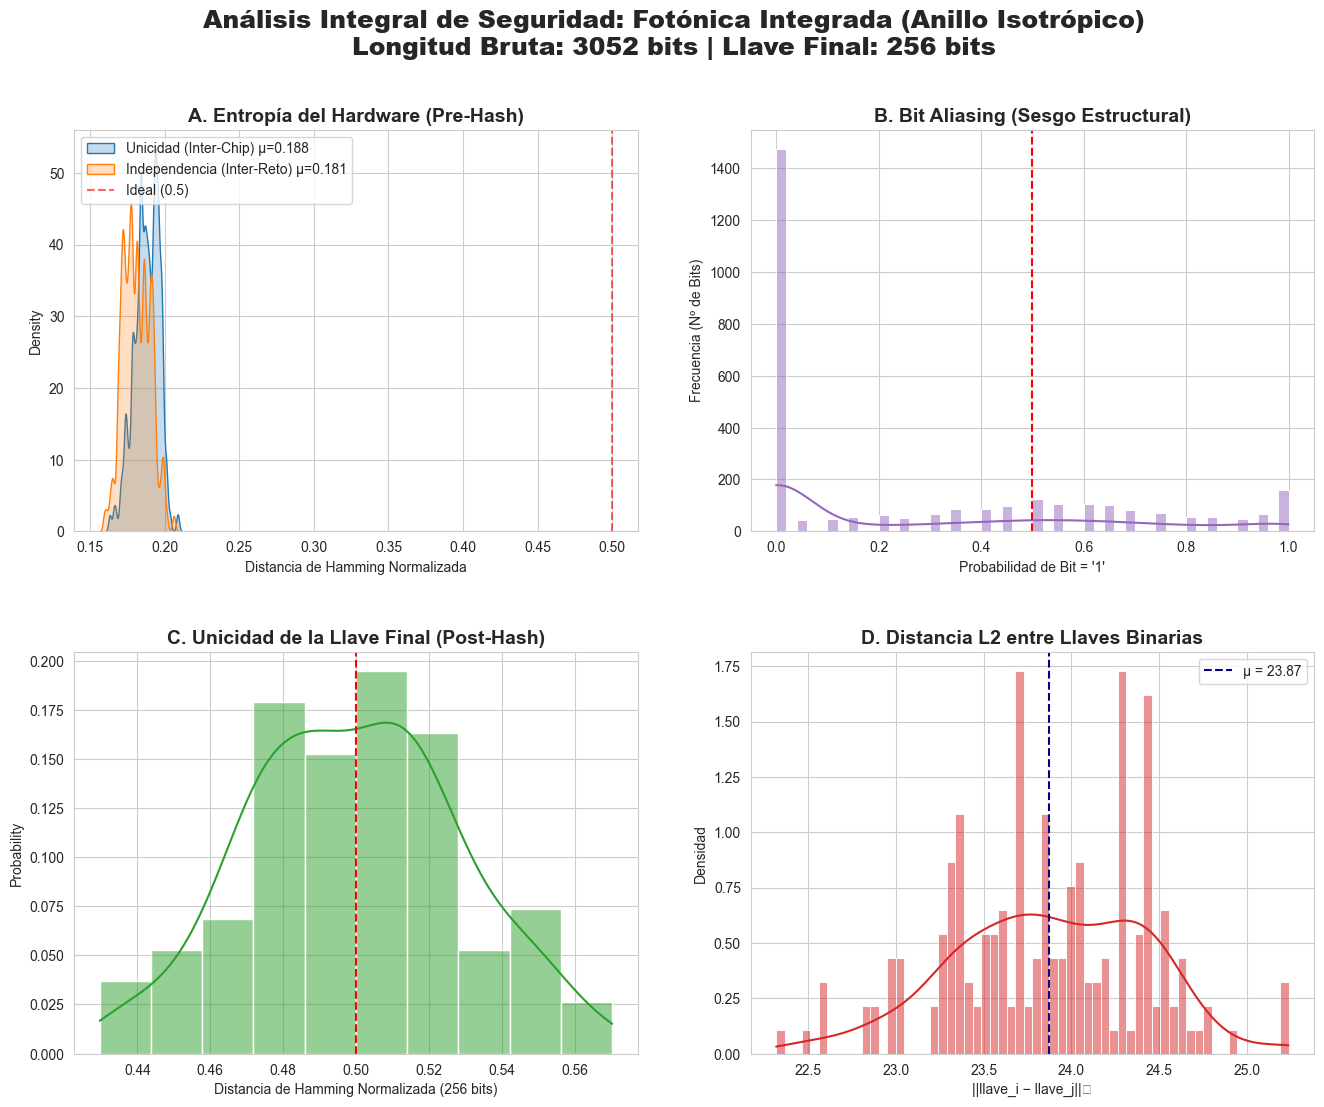


╔══════════════════════════════════════════════════════════╗
║      MÉTRICA DE SEGURIDAD      |  PRE-HASH  | POST-HASH  ║
╠══════════════════════════════════════════════════════════╣
║ Unicidad (HD media)            |   0.1877   |   0.4995   ║
║ Independencia (HD media)       |   0.1809   |   0.5013   ║
║ Uniformidad (Bias)             |   0.2907   |   0.4953   ║
║ Bit Aliasing (Desv. Med)       |   0.3597   |   0.0000   ║
╚══════════════════════════════════════════════════════════╝


{'unicidad_pre': 0.18766323066841414,
 'unicidad_post': 0.4994654605263158,
 'independencia_pre': 0.18087980340760157,
 'independencia_post': 0.5013157894736842,
 'uniformidad_pre': 0.2906782437745741,
 'uniformidad_post': 0.4953125,
 'bit_aliasing_desv': 0.3597477064220183,
 'l2_media': 23.87153925644724,
 'n_chips': 20,
 'n_bits': 3052}

In [2]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
from smartlight_puf_ipronics import (
    _calcular_H_rapido,
    PUERTOS_ACTIVOS_IPRONICS,
)
import numpy as np
import os

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
N = len(PUERTOS_ACTIVOS_IPRONICS)
delta_phi = 2 * np.pi / 256

def estado_a_fases(estado):
    if estado == "x":   return (0.0, 0.0)
    elif estado == "=": return (np.pi, 0.0)
    elif isinstance(estado, (int, float)):
        return (2*np.arcsin(np.sqrt(float(estado))), 0.0)
    return (float(estado[0]), float(estado[1]))

def aplicar_adn_chip(smart, seed):
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

def capturar_matriz_rapido(smart, ruta_anillo_config, seed_reto):
    """
    Captura la matriz N×N usando _calcular_H_rapido (SMM directo).
    50x más rápido que get_spectral_response.
    """
    wma = smart.get_wma()
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)

    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS_IPRONICS):
        ruta_puerto = ruta_anillo_config.get(p_in, [])
        tbus_fijas_puerto = {t[0] for t in ruta_puerto}
        ruta_dict = {puc_id: estado for puc_id, estado in ruta_puerto}

        # Programar fases del reto
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            if puc_id not in tbus_fijas_puerto:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                wma.pucs[puc_id].driven_phases = np.array([fase, 0.0])
            else:
                phi1, phi2 = estado_a_fases(ruta_dict[puc_id])
                passive = wma.pucs[puc_id].passive_phase
                wma.pucs[puc_id].driven_phases = np.array([phi1 - passive, phi2])

        # Calcular H con motor SMM rápido
        H = _calcular_H_rapido(smart, PUERTOS_ACTIVOS_IPRONICS)

        idx_in_local = PUERTOS_ACTIVOS_IPRONICS.index(p_in)
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS_IPRONICS):
            if p_out != p_in:
                matriz[idx_fila, idx_col] = H[idx_fila, idx_in_local]

    return matriz

# Parámetros
N_CHIPS = 20
N_RETOS = 20
DIR_OUT = 'db_sdk_rapido'
os.makedirs(DIR_OUT, exist_ok=True)

smart = Smartlight(filepath=filepath, simulation=True)

print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos (motor rápido)...")
for chip_idx in range(N_CHIPS):
    seed_hw = 7000 + chip_idx
    fname = os.path.join(DIR_OUT, f'chip_{seed_hw}.npz')
    if os.path.exists(fname):
        print(f"  Chip {chip_idx+1}/{N_CHIPS} — ya existe"); continue

    print(f"  Chip {chip_idx+1}/{N_CHIPS} (seed={seed_hw})...",
          end=' ', flush=True)
    aplicar_adn_chip(smart, seed=seed_hw)

    base = capturar_matriz_rapido(smart, rutas_maestras_anillo,
                                   seed_reto=seed_hw + 777)
    retos = [capturar_matriz_rapido(smart, rutas_maestras_anillo,
                                     seed_reto=seed_hw + r + 1)
             for r in range(N_RETOS)]

    np.savez_compressed(fname,
                        base_anillo=base,
                        anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print("OK")

smart.disconnect()

generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

In [ ]:
from pathlib import Path
from smartlight.smartlight import Smartlight
from smartlight_puf_v3 import (
    binarizar_puf_lehmer_por_columnas,
    rutas_maestras_anillo,
    generar_llaves_npz,
    analizar_puf_tfm_final,
)
import numpy as np
import os

filepath = Path.cwd() / "res/hw_config_virtual_amf_s.smartlight"
PUERTOS_ACTIVOS = [i for i in range(40) if i < 22 or i > 33]
N = len(PUERTOS_ACTIVOS)
delta_phi = 2 * np.pi / 256

def aplicar_adn_chip(smart, seed):
    """Simula variabilidad de fabricación cambiando fases pasivas."""
    rng = np.random.default_rng(seed)
    for puc in smart.get_wma().pucs:
        fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
        puc.set_passive_phase_design(fase)

def capturar_matriz_con_reto_sdk(smart, ruta_anillo_config, seed_reto):
    """
    Captura la matriz N×N usando get_spectral_response del SDK.
    Programa el reto con set_driven_phases (sin reset_mesh) para
    preservar las fases aleatorias entre puertos.
    """
    wma = smart.get_wma()
    pp = smart.get_photonic_processor()
    mapping = pp.mapping_wma_mua
    n_pucs = len(wma.pucs)
    matriz = np.zeros((N, N), dtype=np.float32)

    for idx_col, p_in in enumerate(PUERTOS_ACTIVOS):
        ruta_puerto = ruta_anillo_config.get(p_in, [])
        tbus_fijas_puerto = {t[0] for t in ruta_puerto}

        # 1. Programar fases aleatorias en TBUs dinámicas
        rng = np.random.default_rng(seed_reto + idx_col)
        for puc_id in range(n_pucs):
            if puc_id not in tbus_fijas_puerto:
                fase = round(rng.uniform(0, 2*np.pi) / delta_phi) * delta_phi
                smart.set_driven_phases(puc_id, [fase, 0.0])

        # 2. Programar ruta del Anillo encima (sin reset_mesh)
        smart.interconnect(ruta_puerto)

        # 3. Leer potencias
        puertos_salida = [p for p in PUERTOS_ACTIVOS if p != p_in]
        smart.get_spectral_response(inport=p_in, outports=puertos_salida)

        H = pp.measured_scattering_matrix["scattering_matrix"]
        idx_in_pp = mapping[p_in]
        for idx_fila, p_out in enumerate(PUERTOS_ACTIVOS):
            if p_out != p_in:
                idx_out_pp = mapping[p_out]
                matriz[idx_fila, idx_col] = abs(H[0, idx_out_pp, idx_in_pp])**2

    return matriz

# Parámetros
N_CHIPS = 10
N_RETOS = 10
DIR_OUT = 'db_sdk_v3'
os.makedirs(DIR_OUT, exist_ok=True)

smart = Smartlight(filepath=filepath, simulation=True)

print(f"Simulando {N_CHIPS} chips x {N_RETOS} retos con SDK iPronics...")
for chip_idx in range(N_CHIPS):
    seed_hw = 7000 + chip_idx
    fname = os.path.join(DIR_OUT, f'chip_{seed_hw}.npz')
    if os.path.exists(fname):
        print(f"  Chip {chip_idx+1}/{N_CHIPS} — ya existe"); continue

    print(f"  Chip {chip_idx+1}/{N_CHIPS} (seed={seed_hw})...",
          end=' ', flush=True)
    aplicar_adn_chip(smart, seed=seed_hw)

    base = capturar_matriz_con_reto_sdk(smart, rutas_maestras_anillo,
                                         seed_reto=seed_hw + 777)
    retos = [capturar_matriz_con_reto_sdk(smart, rutas_maestras_anillo,
                                           seed_reto=seed_hw + r + 1)
             for r in range(N_RETOS)]

    np.savez_compressed(fname,
                        base_anillo=base,
                        anillo=np.array(retos),
                        seed_hw=np.array(seed_hw))
    print("OK")

smart.disconnect()
print("Simulación completada.")

generar_llaves_npz(DIR_OUT)
analizar_puf_tfm_final('llaves_binarizadas_lehmer_columnas.npz')

Simulando 10 chips x 10 retos con SDK iPronics...
  Chip 1/10 (seed=7000)... 